In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
def plot_multi_gaussian(q, i = 0, alpha = 1.96, linestyle = '-'):
    """
    Plot all dimensions of the ith observation
    """
    
    mu, var = np.array(q.mean.detach().numpy())[i], np.array(q.variance.detach().numpy())[i]**.5

    plt.plot(mu, linestyle = linestyle);
   
    plt.gca().set_prop_cycle(None)
    for j in range(var.shape[-1]):
        low, up = (mu - alpha*var)[:,j], (mu + alpha*var)[:,j]
        plt.fill_between(np.arange(mu.shape[0]), low, up, alpha = .2);

def plot_reconstructions(X, X_ori, q, model, i = 0, n_samples = 100, ax = None):
    """
    Given the observed data X, the latent distribution q and the model (for the decoder) plots the reconstructions
    """

    z = q.rsample((n_samples,))
    #print(z[0,0,0])
    #print(z[1,0,0])
    #print('**')
    #z = q.mean.repeat((100,1,1,1))

    #print(z.shape, X.shape)

    X_recon = np.array(model.model.backbone.decoder(z).mean.detach().numpy())[:,i]

    if ax is None:
        fig, ax = plt.subplots(figsize=(18,8))

    # plot X
    X = np.array(X.detach().numpy())
    X_ori = np.array(X_ori.detach().numpy())

    X[X==0] = np.nan
    ax.plot(X[i], 'o');
    ax.set_prop_cycle(None)
    ax.plot(X_ori[i], '+');
    ax.set_prop_cycle(None)

    #for j in range(n_samples):
    #    ax.plot(X_recon[j], alpha = .05)
    #    ax.set_prop_cycle(None)
    low, up = X_recon.min(axis=0), X_recon.max(axis=0)
    for j in range(X_recon.shape[-1]):
        ax.fill_between(np.arange(X.shape[1]), low[:,j], up[:,j], alpha = .3)

    ax.set_prop_cycle(None)
    ax.plot(X_recon.mean(axis=0))

    scale_factor = 1.5
    ymin, ymax = np.nanmin(X[i])*scale_factor, np.nanmax(X[i])*scale_factor
    ax.set_ylim([ymin,ymax])
    

In [3]:
import random
random.seed(9001)

In [4]:
from PyPOTS_gp_benchmark_helpers import artifical_GP_generation

dataset_train_nan, dataset_val_nan, dataset_train, dataset_val, X_normalized, X = artifical_GP_generation(n_observations_per_group = 500,
                                                n_dimensions = 3,
                                                n_time_points = 30,
                                                n_new_dims = 7,
                                                p_dataset = 0.8)

100%|██████████| 500/500 [00:00<00:00, 2458.16it/s]


In [5]:
import sys
sys.path.append("..")

In [6]:
from pypots.optim import Adam
from pypots.imputation import SAITS

# initialize the model
saits = SAITS(
    n_steps=30,
    n_features=7,
    n_layers=2,
    d_model=256,
    d_ffn=128,
    n_heads=4,
    d_k=64,
    d_v=64,
    dropout=0.1,
    attn_dropout=0.1,
    diagonal_attention_mask=True,  # otherwise the original self-attention mechanism will be applied
    ORT_weight=1,  # you can adjust the weight values of arguments ORT_weight
    # and MIT_weight to make the SAITS model focus more on one task. Usually you can just leave them to the default values, i.e. 1.
    MIT_weight=1,
    batch_size=32,
    # here we set epochs=10 for a quick demo, you can set it to 100 or more for better performance
    epochs=300,
    # here we set patience=3 to early stop the training if the evaluting loss doesn't decrease for 3 epoches.
    # You can leave it to defualt as None to disable early stopping.
    patience=3,
    # give the optimizer. Different from torch.optim.Optimizer, you don't have to specify model's parameters when
    # initializing pypots.optim.Optimizer. You can also leave it to default. It will initilize an Adam optimizer with lr=0.001.
    optimizer=Adam(lr=1e-3),
    # this num_workers argument is for torch.utils.data.Dataloader. It's the number of subprocesses to use for data loading.
    # Leaving it to default as 0 means data loading will be in the main process, i.e. there won't be subprocesses.
    # You can increase it to >1 if you think your dataloading is a bottleneck to your model training speed
    num_workers=0,
    # just leave it to default as None, PyPOTS will automatically assign the best device for you.
    # Set it as 'cpu' if you don't have CUDA devices. You can also set it to 'cuda:0' or 'cuda:1' if you have multiple CUDA devices, even parallelly on ['cuda:0', 'cuda:1']
    device=None,  
    # set the path for saving tensorboard and trained model files 
    saving_path="tutorial_results/imputation/saits",
    # only save the best model after training finished.
    # You can also set it as "better" to save models performing better ever during training.
    model_saving_strategy="best",
)

/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
/Users/vincente/Documents/Vie Pro/Phd/Code/Code_pour_manuscript/PyPOTS/ipynbs/../pypots/nn/modules/reformer/local_attention.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)
2025-06-28 14:02:37 [INFO]: No given device, using default device: cpu
2025-06-28 14:02:37 [INFO]: Model files will be saved to tutorial_results/imputation/saits/20250628_T140237
2025-06-28 14:02:37 [INFO]: Tensorboard file will be saved to tutorial_results/imputation/saits/20250628_T140237/tensorboard
2025-06-28 14:02:37 [INFO]: SAITS initialized with the given hyperparameters, the number of trainable parameters: 1,327,952



████████╗██╗███╗   ███╗███████╗    ███████╗███████╗██████╗ ██╗███████╗███████╗    █████╗ ██╗
╚══██╔══╝██║████╗ ████║██╔════╝    ██╔════╝██╔════╝██╔══██╗██║██╔════╝██╔════╝   ██╔══██╗██║
   ██║   ██║██╔████╔██║█████╗█████╗███████╗█████╗  ██████╔╝██║█████╗  ███████╗   ███████║██║
   ██║   ██║██║╚██╔╝██║██╔══╝╚════╝╚════██║██╔══╝  ██╔══██╗██║██╔══╝  ╚════██║   ██╔══██║██║
   ██║   ██║██║ ╚═╝ ██║███████╗    ███████║███████╗██║  ██║██║███████╗███████║██╗██║  ██║██║
   ╚═╝   ╚═╝╚═╝     ╚═╝╚══════╝    ╚══════╝╚══════╝╚═╝  ╚═╝╚═╝╚══════╝╚══════╝╚═╝╚═╝  ╚═╝╚═╝
ai4ts v0.0.3 - building AI for unified time-series analysis, https://time-series.ai 



In [ ]:
# Model training. This is PyPOTS showtime.
from pypots.imputation import GP_UAE
from pypots.utils.metrics import calc_mae
from pypots.optim.adam import Adam
from torch.optim.lr_scheduler import LRScheduler

gpuae = GP_UAE(n_steps = dataset_train['X'].shape[1], 
            n_features = dataset_train['X'].shape[2], 
            latent_size = 6, 
            epochs = 500, 
            batch_size = 64,
            alpha = .5,
            beta = 10, 
            sigma = 1e-2,
            K = 1,  
            #encoder_sizes = (256,128,), 
            #decoder_sizes = (128,128,),
            encoder_sizes = (128, 128,), 
            decoder_sizes = (128,128,),
            optimizer = Adam(weight_decay=0.001), #lr = 1e-4
            patience = 3000,
            p = 'curriculum learning',
            )

gpuae.use_gp = False
gpuae.train_gp = False
gpuae.gp.plot_while_training = True
gpuae.model.backbone.device = 'cpu'

from sklearn.impute import KNNImputer
X = dataset_train_nan['X']
imputer = KNNImputer(n_neighbors=2)
imputer.fit(X.reshape(-1,7))

gpuae.model.backbone.encoder.pre_imputer = imputer
gpuae.model.backbone.encoder.pre_impute = True

2025-06-28 14:04:41 [INFO]: No given device, using default device: cpu
2025-06-28 14:04:41 [WARNING]: ‼️ saving_path not given. Model files and tensorboard file will not be saved.
2025-06-28 14:04:41 [INFO]: GP_UAE initialized with the given hyperparameters, the number of trainable parameters: 56,595


Model dimensions is:
GpvaeEncoder(
  (net): Sequential(
    (0): Linear(in_features=14, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (mu_layer): Linear(in_features=128, out_features=6, bias=True)
  (logvar_layer): Linear(in_features=128, out_features=6, bias=True)
  (dropout): Dropout(p=0.01, inplace=False)
)
GpvaeDecoder(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [ ]:
import torch
#with torch.autograd.set_detect_anomaly(True):
gpuae.fit(dataset_train_nan, dataset_val_nan)  # train the model on the dataset

2025-06-28 14:04:43 [INFO]: Epoch 001 - training loss: 402.6729, validation loss: 366.4140
2025-06-28 14:04:43 [INFO]: Epoch 002 - training loss: 376.6323, validation loss: 328.6825
2025-06-28 14:04:44 [INFO]: Epoch 003 - training loss: 309.3339, validation loss: 226.2814
2025-06-28 14:04:44 [INFO]: Epoch 004 - training loss: 171.0559, validation loss: 104.9543
2025-06-28 14:04:45 [INFO]: Epoch 005 - training loss: 100.5316, validation loss: 75.9533
2025-06-28 14:04:45 [INFO]: Epoch 006 - training loss: 64.4138, validation loss: 58.7713
2025-06-28 14:04:46 [INFO]: Epoch 007 - training loss: 53.8130, validation loss: 41.3167
2025-06-28 14:04:46 [INFO]: Epoch 008 - training loss: 37.4569, validation loss: 32.6040
2025-06-28 14:04:47 [INFO]: Epoch 009 - training loss: 31.4697, validation loss: 25.8844
2025-06-28 14:04:47 [INFO]: Epoch 010 - training loss: 25.2372, validation loss: 21.5426
2025-06-28 14:04:47 [INFO]: Epoch 011 - training loss: 21.5416, validation loss: 19.1206
2025-06-28 1

Plotting latent series and reconstruction...


2025-06-28 14:05:10 [INFO]: Epoch 056 - training loss: 2.9496, validation loss: 2.5084
2025-06-28 14:05:11 [INFO]: Epoch 057 - training loss: 2.9580, validation loss: 2.5014
2025-06-28 14:05:11 [INFO]: Epoch 058 - training loss: 2.8928, validation loss: 2.4705
2025-06-28 14:05:12 [INFO]: Epoch 059 - training loss: 2.8676, validation loss: 2.5192
2025-06-28 14:05:12 [INFO]: Epoch 060 - training loss: 2.8403, validation loss: 2.4228
2025-06-28 14:05:13 [INFO]: Epoch 061 - training loss: 2.8247, validation loss: 2.4094
2025-06-28 14:05:13 [INFO]: Epoch 062 - training loss: 2.7586, validation loss: 2.3215
2025-06-28 14:05:14 [INFO]: Epoch 063 - training loss: 2.7001, validation loss: 2.3592
2025-06-28 14:05:14 [INFO]: Epoch 064 - training loss: 2.7199, validation loss: 2.3426
2025-06-28 14:05:15 [INFO]: Epoch 065 - training loss: 2.6600, validation loss: 2.2891
2025-06-28 14:05:15 [INFO]: Epoch 066 - training loss: 2.6364, validation loss: 2.2032
2025-06-28 14:05:16 [INFO]: Epoch 067 - tra

Plotting latent series and reconstruction...


2025-06-28 14:05:38 [INFO]: Epoch 112 - training loss: 1.6370, validation loss: 1.3881
2025-06-28 14:05:38 [INFO]: Epoch 113 - training loss: 1.6186, validation loss: 1.3726
2025-06-28 14:05:39 [INFO]: Epoch 114 - training loss: 1.5887, validation loss: 1.3651
2025-06-28 14:05:39 [INFO]: Epoch 115 - training loss: 1.5592, validation loss: 1.3116
2025-06-28 14:05:40 [INFO]: Epoch 116 - training loss: 1.5475, validation loss: 1.2749
2025-06-28 14:05:40 [INFO]: Epoch 117 - training loss: 1.5332, validation loss: 1.2319
2025-06-28 14:05:41 [INFO]: Epoch 118 - training loss: 1.5487, validation loss: 1.2515
2025-06-28 14:05:41 [INFO]: Epoch 119 - training loss: 1.5328, validation loss: 1.2138


training kernel


0it [00:00, ?it/s]

0.003436307655647397 0.18287034332752228


2it [00:00,  3.46it/s]

0.0036500159185379744 0.148044615983963


...

0.003522164886817336 0.19243548810482025


5it [00:01,  3.78it/s]

0.004533552099019289 0.16286581754684448
0.004329150076955557 0.11273056268692017


6it [00:01,  4.05it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


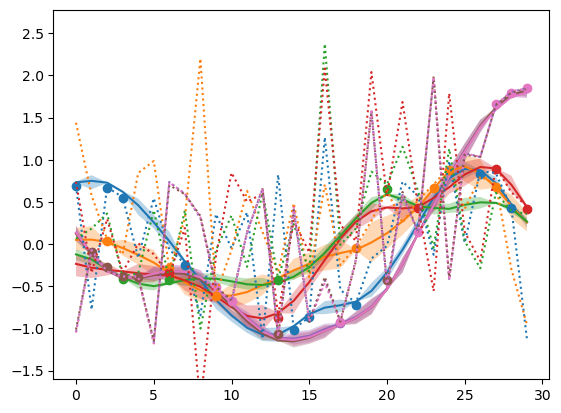

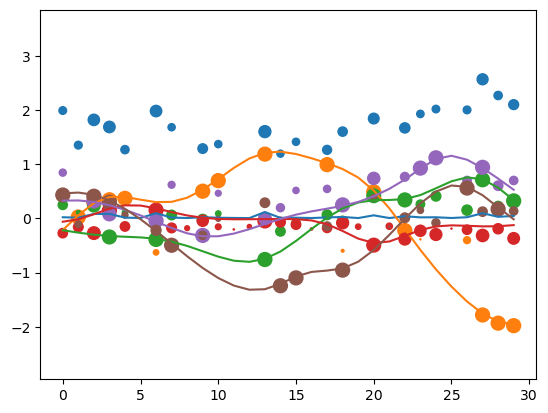

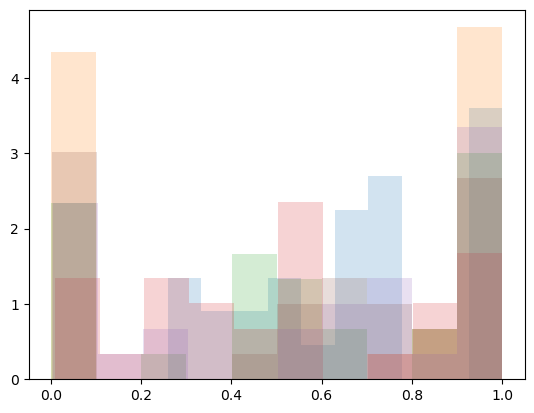

Epoch 2/500: Training Loss = 0.078251, Validation Loss = 0.160412


0it [00:00, ?it/s]

0.004006051924079657 0.12979364395141602


2it [00:00,  4.32it/s]

0.0039313919842243195 0.15171529352664948


...

0.003651304403319955 0.19119618833065033


5it [00:01,  3.71it/s]

0.0035572315100580454 0.14725230634212494


6it [00:01,  4.19it/s]


0.0026457682251930237 0.19399422407150269
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


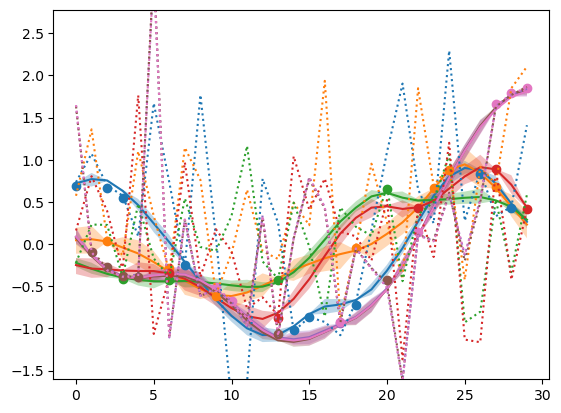

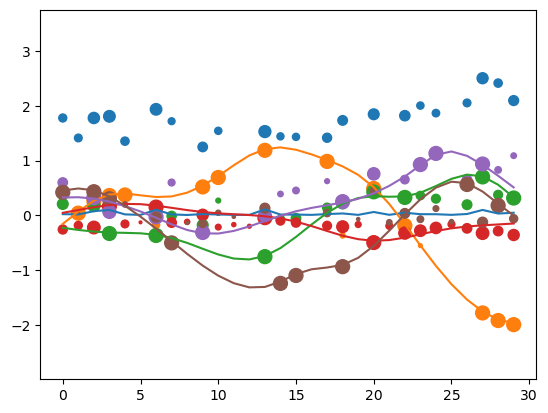

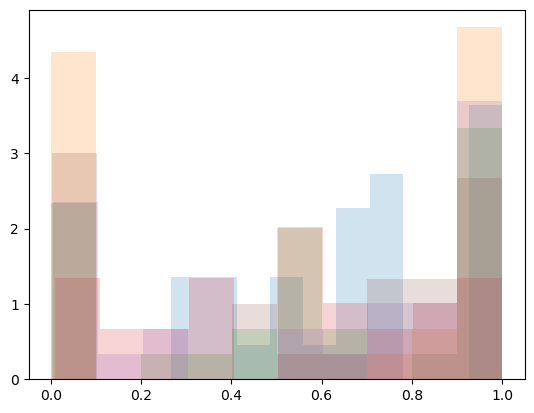

Epoch 3/500: Training Loss = 0.076815, Validation Loss = 0.153692


0it [00:00, ?it/s]

0.003520670812577009 0.1670592725276947


2it [00:00,  4.29it/s]

0.003639523172751069 0.14529061317443848


...

0.0035764414351433516 0.1489659696817398


5it [00:02,  2.21it/s]

0.003410924691706896 0.14618726074695587


6it [00:02,  2.54it/s]


0.00337140541523695 0.12209716439247131
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


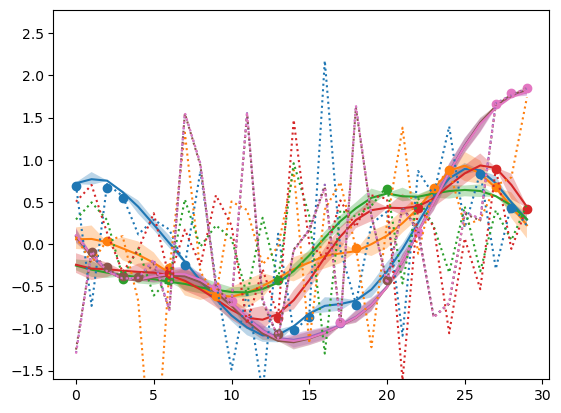

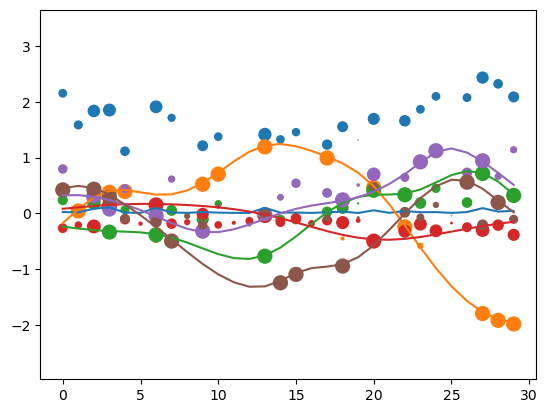

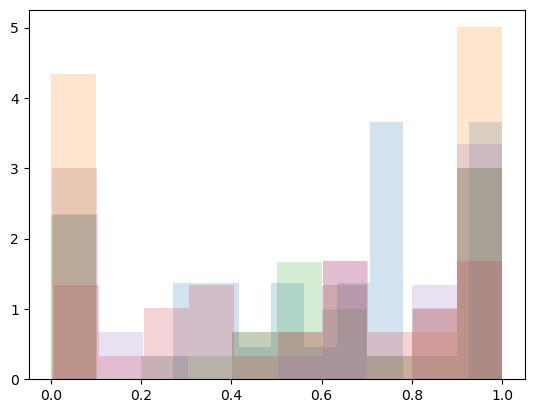

Epoch 4/500: Training Loss = 0.073245, Validation Loss = 0.161870


0it [00:00, ?it/s]

0.0036760414950549603 0.13540484011173248


2it [00:00,  3.60it/s]

0.00345116900280118 0.13895323872566223


...

0.0038334187120199203 0.17408548295497894


5it [00:01,  3.62it/s]

0.0033233186695724726 0.18764446675777435


6it [00:01,  3.99it/s]


0.0042944420129060745 0.1487549990415573
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


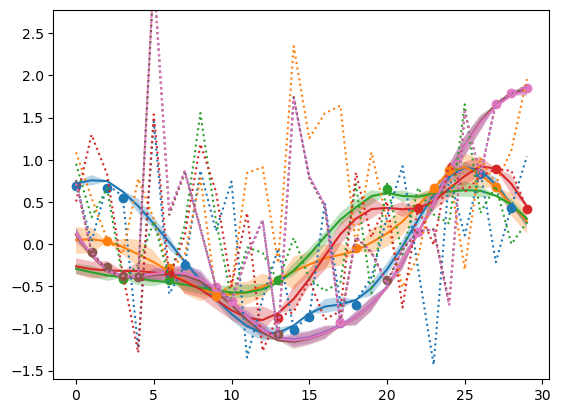

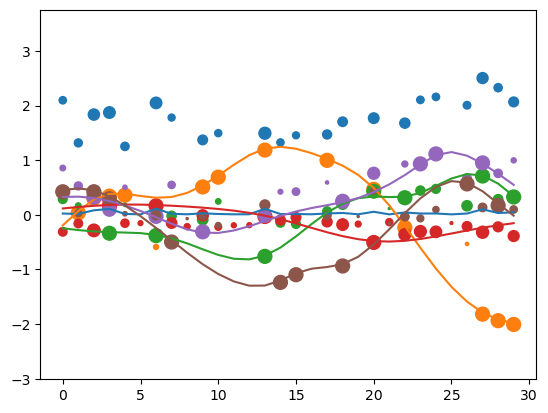

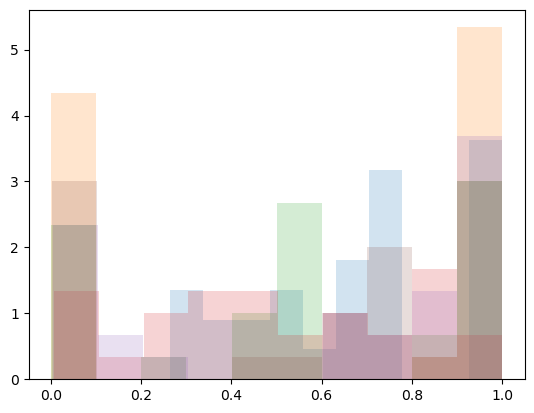

Epoch 5/500: Training Loss = 0.077445, Validation Loss = 0.158806


0it [00:00, ?it/s]

0.0030687139369547367 0.16179797053337097


2it [00:00,  3.98it/s]

0.003575858660042286 0.14671653509140015


...

0.0032214003149420023 0.18621961772441864


5it [00:01,  3.90it/s]

0.0034299392718821764 0.1454833596944809
0.003264449303969741 0.10874850302934647


6it [00:01,  4.27it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


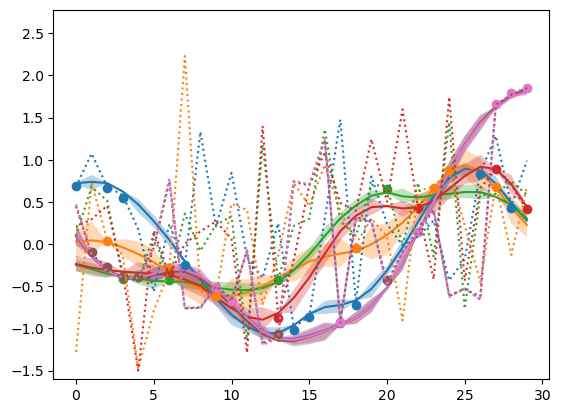

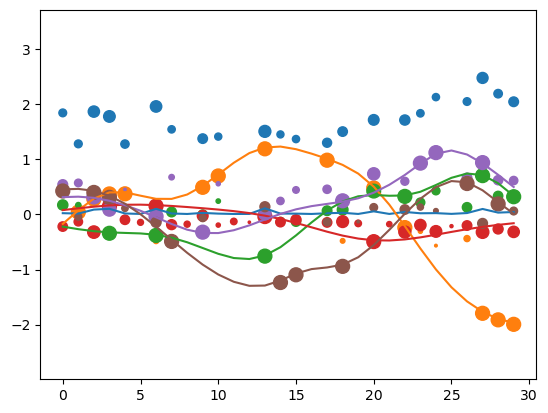

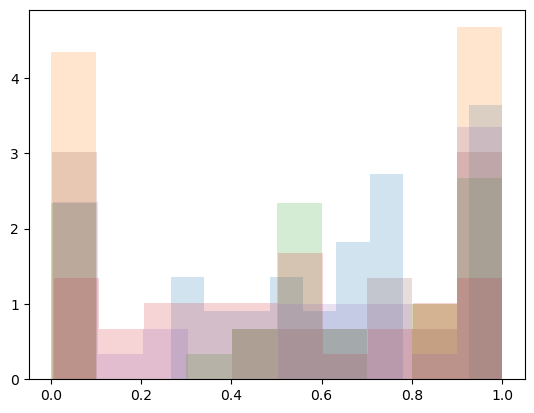

Epoch 6/500: Training Loss = 0.074511, Validation Loss = 0.144151


0it [00:00, ?it/s]

0.003394664730876684 0.15871857106685638


2it [00:00,  3.48it/s]

0.0037100138142704964 0.22185729444026947


...

0.0034344405867159367 0.17353346943855286


5it [00:01,  3.64it/s]

0.0031035637948662043 0.1488894671201706
0.0032017193734645844 0.15263698995113373


6it [00:01,  3.96it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


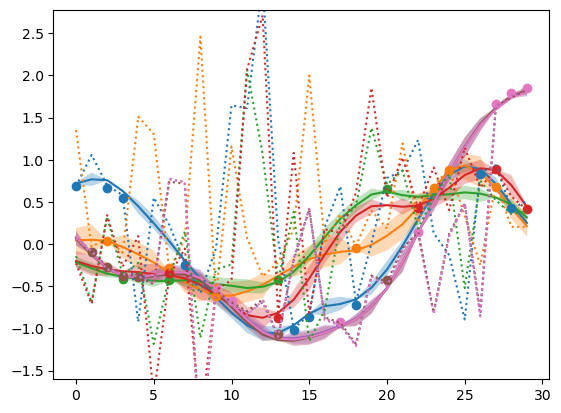

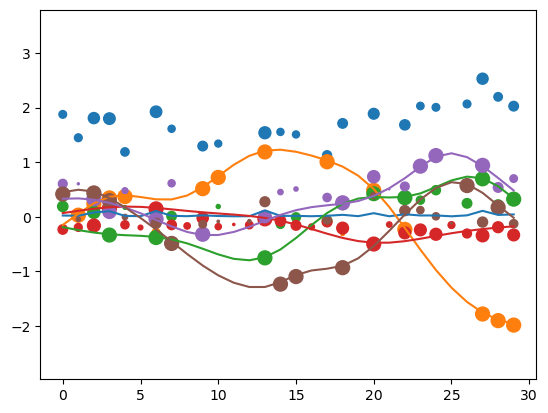

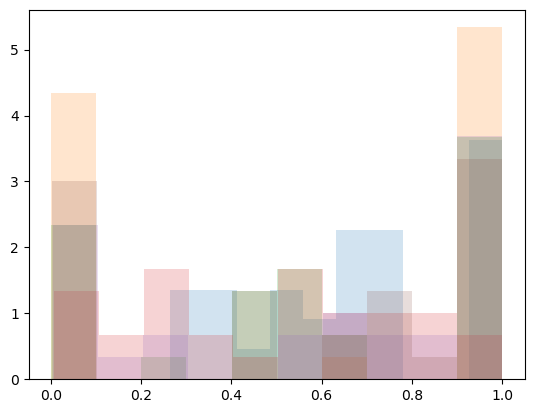

Epoch 7/500: Training Loss = 0.079504, Validation Loss = 0.156048


0it [00:00, ?it/s]

0.0034188793506473303 0.15094920992851257


2it [00:00,  3.41it/s]

0.0033006970770657063 0.1266227811574936


...

0.003689422272145748 0.1589316725730896


5it [00:01,  3.48it/s]

0.0031934077851474285 0.1244455948472023


6it [00:01,  3.72it/s]


0.004020348656922579 0.142363503575325
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


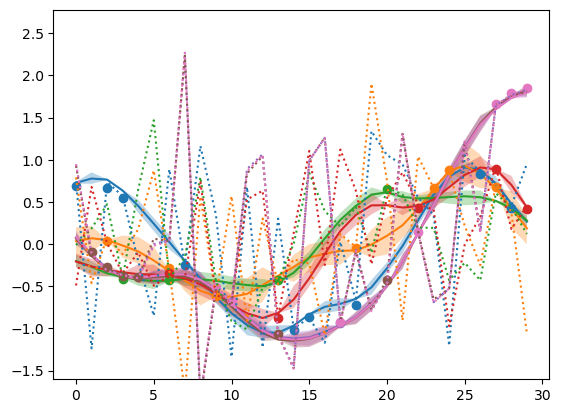

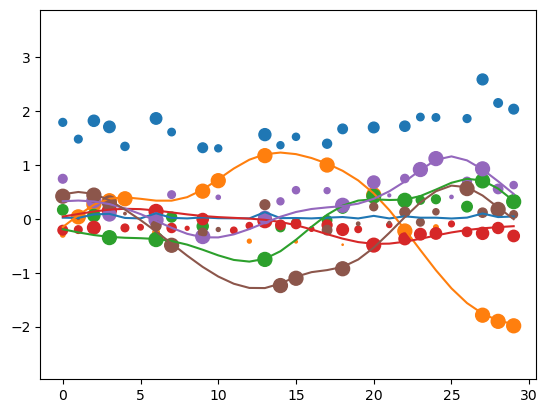

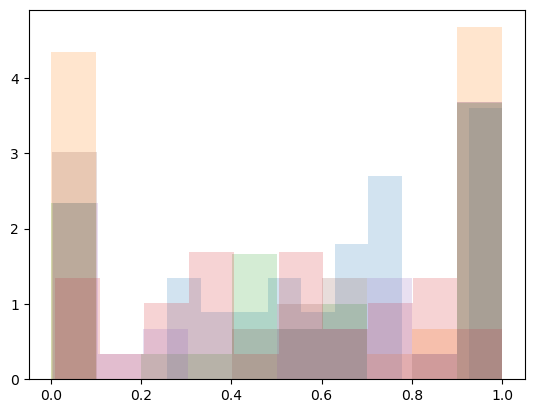

Epoch 8/500: Training Loss = 0.070243, Validation Loss = 0.153730


0it [00:00, ?it/s]

0.0033718885388225317 0.17149968445301056


2it [00:00,  3.69it/s]

0.0032561568077653646 0.15886063873767853


...

0.0027504777535796165 0.14590704441070557


5it [00:01,  3.79it/s]

0.0028636676725000143 0.16490301489830017


6it [00:01,  4.11it/s]


0.0033747588749974966 0.141316756606102
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


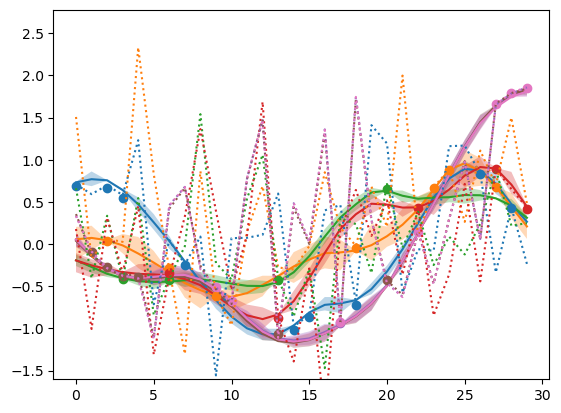

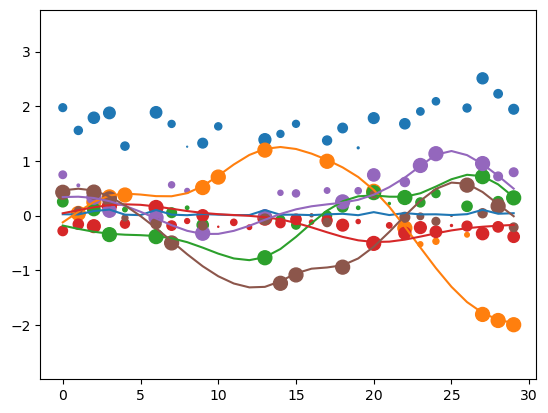

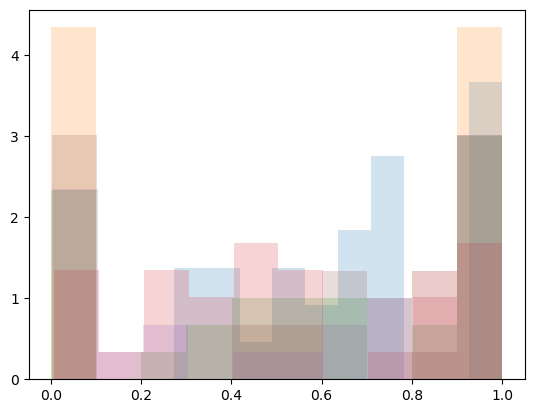

Epoch 9/500: Training Loss = 0.076141, Validation Loss = 0.152136


0it [00:00, ?it/s]

0.003643184434622526 0.18269336223602295


2it [00:00,  3.69it/s]

0.0028293561190366745 0.14674736559391022


...

0.0024862054269760847 0.15770895779132843


5it [00:01,  3.66it/s]

0.003298188326880336 0.17191113531589508
0.003367156255990267 0.13648858666419983


6it [00:01,  4.02it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


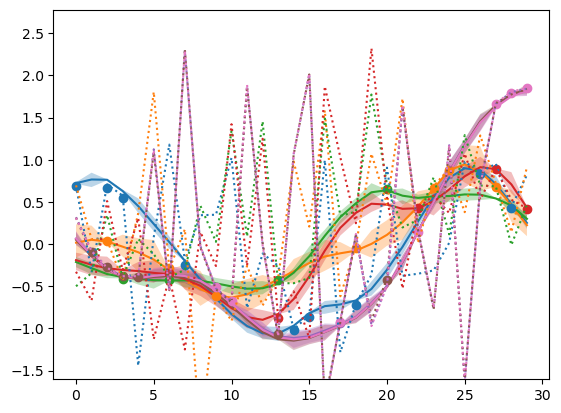

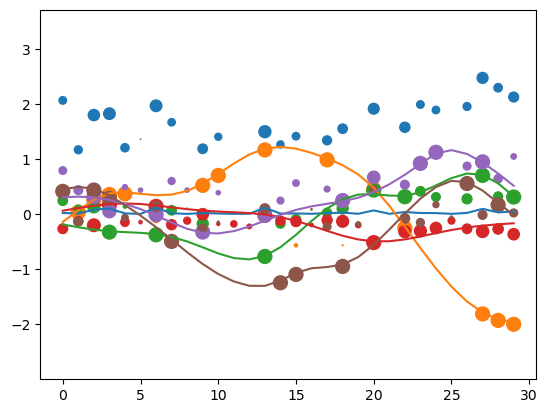

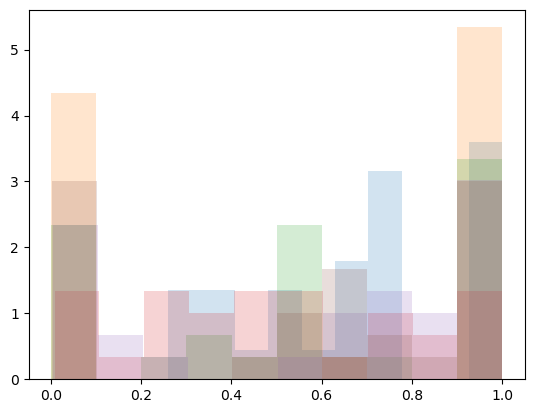

Epoch 10/500: Training Loss = 0.075770, Validation Loss = 0.155971


0it [00:00, ?it/s]

0.0030039057601243258 0.18905965983867645


2it [00:00,  3.77it/s]

0.0029968523886054754 0.1398445963859558


...

0.0036943559534847736 0.14327523112297058


5it [00:01,  3.19it/s]

0.003583646612241864 0.1221679225564003


6it [00:01,  3.59it/s]


0.003469608025625348 0.1191205084323883
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


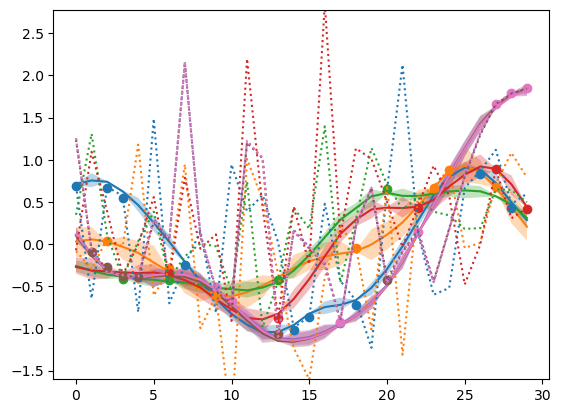

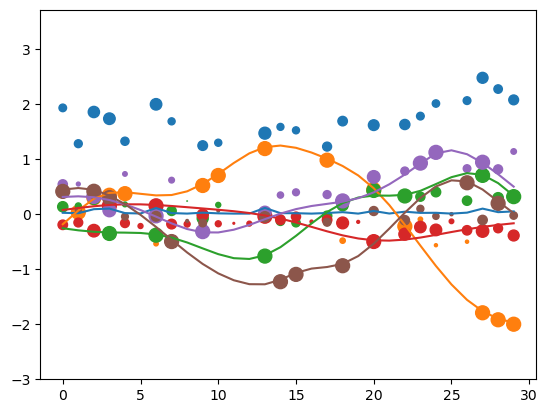

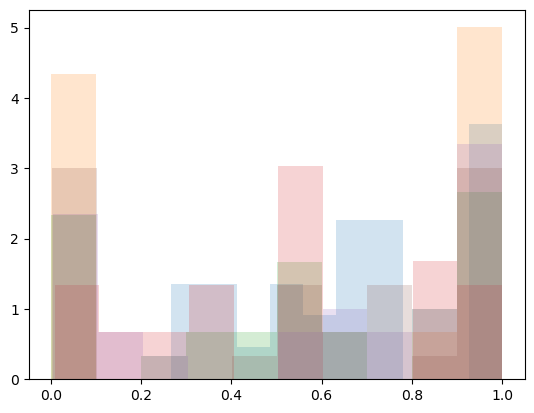

Epoch 11/500: Training Loss = 0.070470, Validation Loss = 0.147398


0it [00:00, ?it/s]

0.0031846894416958094 0.18462592363357544


2it [00:00,  3.64it/s]

0.0030974186956882477 0.15373501181602478


...

0.003889648709446192 0.14786848425865173


5it [00:01,  3.74it/s]

0.0030258039478212595 0.14088347554206848


6it [00:01,  4.02it/s]


0.0033871675841510296 0.09412144124507904
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


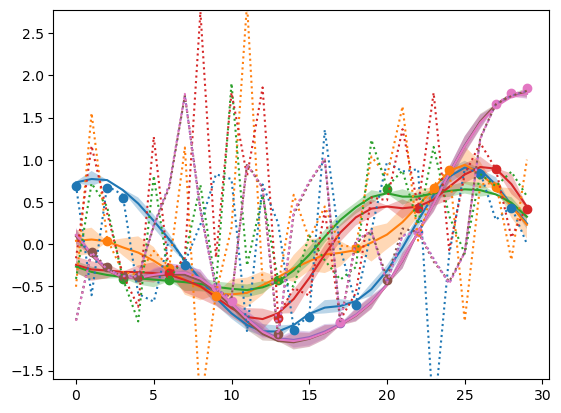

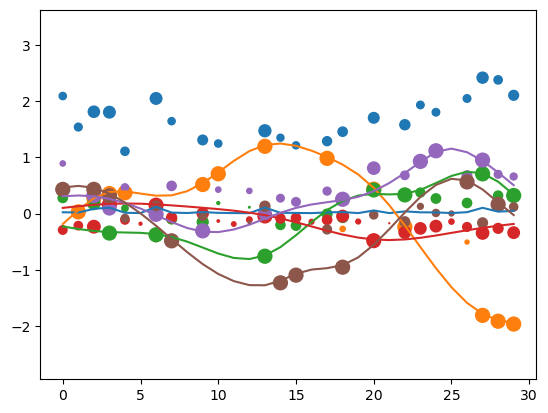

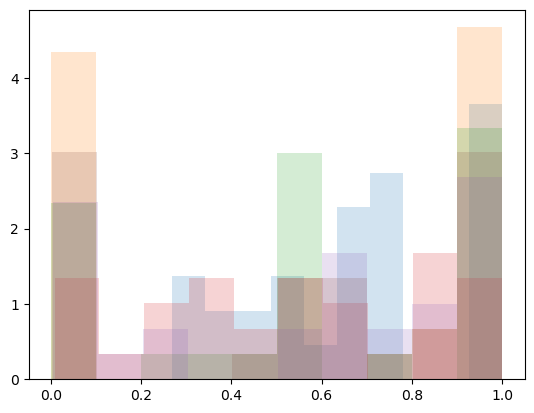

Epoch 12/500: Training Loss = 0.072924, Validation Loss = 0.171090


0it [00:00, ?it/s]

0.003390279831364751 0.15604108572006226


2it [00:00,  3.36it/s]

0.003091850085183978 0.10691449791193008


...

0.0029756873846054077 0.13023371994495392


5it [00:01,  3.71it/s]

0.0030951467342674732 0.1696888655424118


6it [00:01,  3.94it/s]


0.0032783765345811844 0.14236967265605927
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


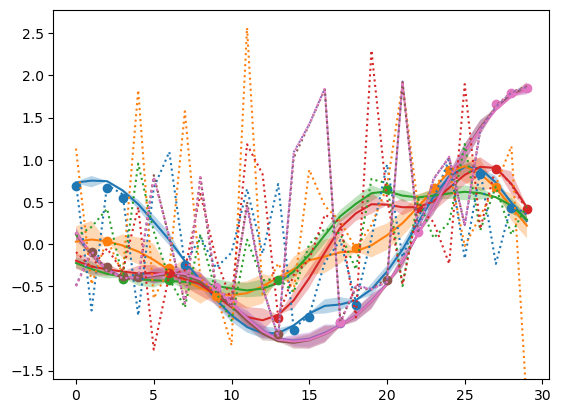

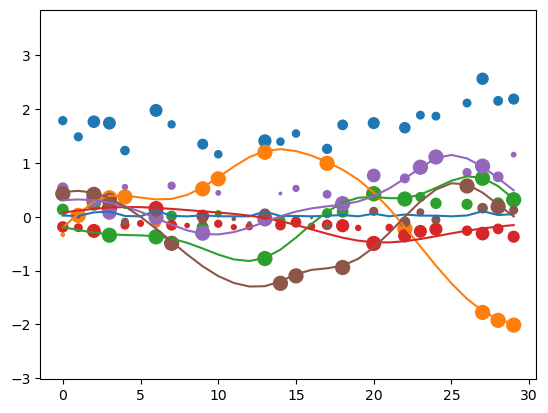

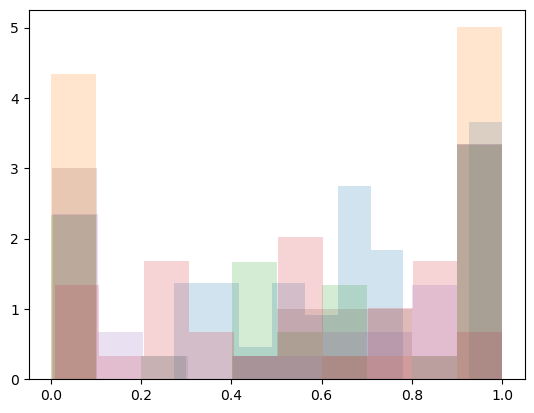

Epoch 13/500: Training Loss = 0.070338, Validation Loss = 0.156106


0it [00:00, ?it/s]

0.003807766828685999 0.17246316373348236


2it [00:00,  3.56it/s]

0.0032073582988232374 0.17386679351329803


...

0.0032129031606018543 0.1157667487859726


5it [00:01,  3.70it/s]

0.0035594196524471045 0.18515770137310028


6it [00:01,  4.05it/s]


0.0027559155132621527 0.13032975792884827
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


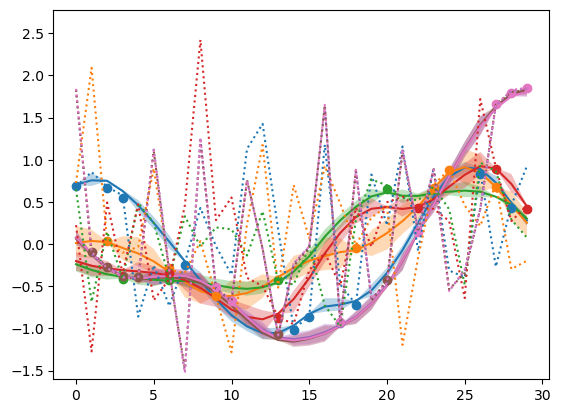

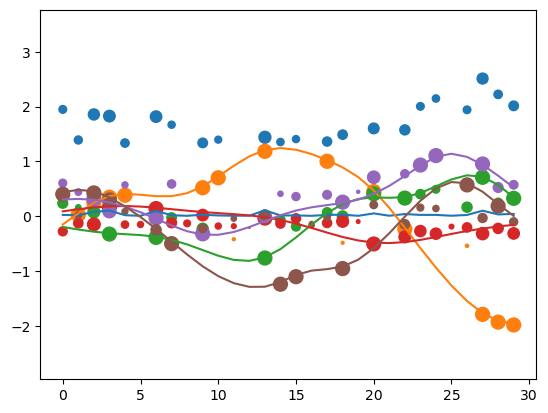

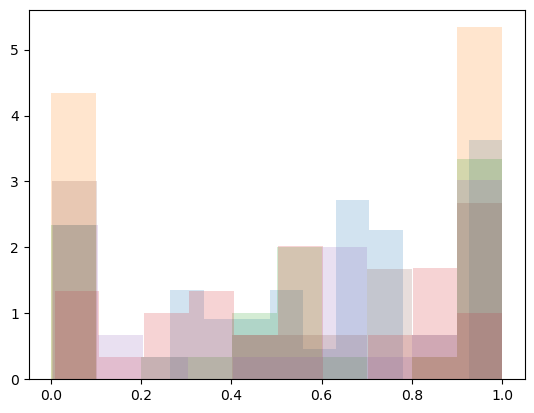

Epoch 14/500: Training Loss = 0.075286, Validation Loss = 0.151033


1it [00:00,  1.83it/s]

0.003287465311586857 0.15197867155075073


2it [00:00,  2.52it/s]

0.003758095670491457 0.1868179589509964


...

0.0028861660975962877 0.10875046253204346


5it [00:01,  3.29it/s]

0.00292613310739398 0.1433955729007721


6it [00:01,  3.31it/s]


0.00388318975456059 0.1341157853603363
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


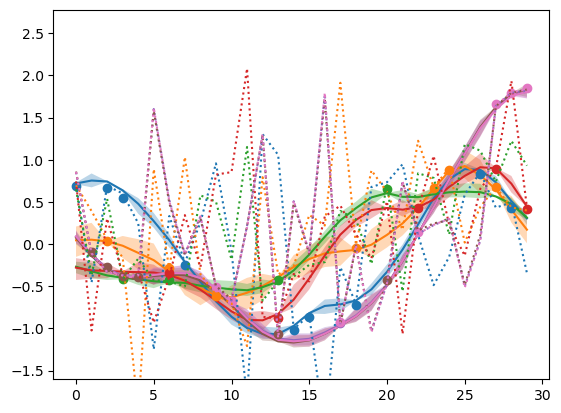

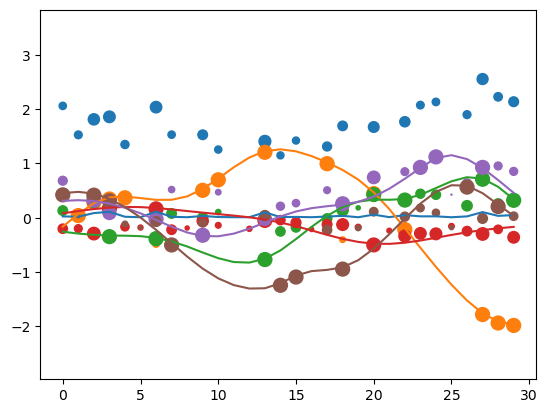

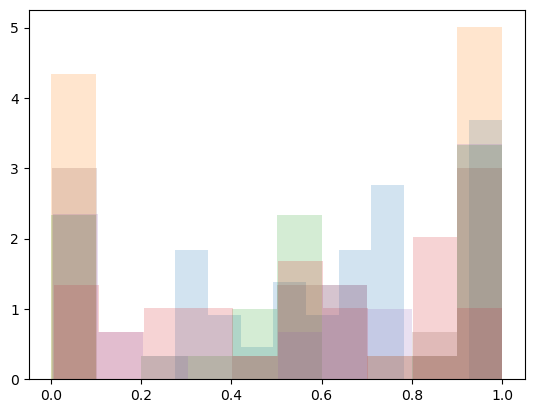

Epoch 15/500: Training Loss = 0.071194, Validation Loss = 0.153820


0it [00:00, ?it/s]

0.0031381016597151756 0.18638765811920166


2it [00:00,  3.44it/s]

0.003340651048347354 0.16025440394878387


...

0.0035779615864157677 0.15039463341236115


5it [00:01,  3.63it/s]

0.0030916971154510975 0.16027794778347015


6it [00:01,  3.95it/s]


0.003966530319303274 0.19956059753894806
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


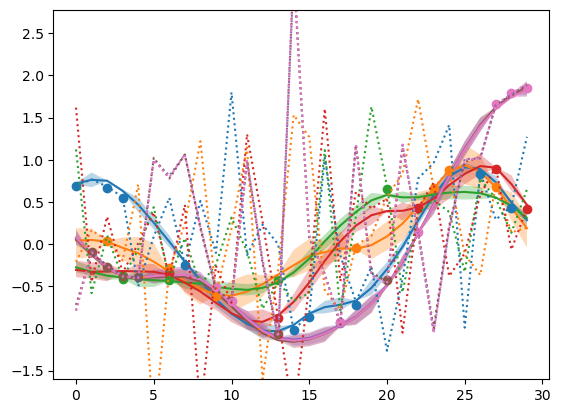

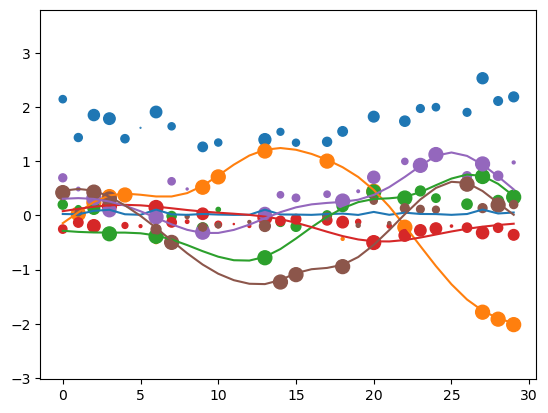

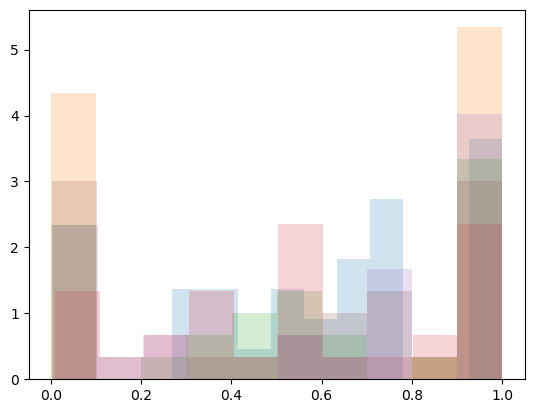

Epoch 16/500: Training Loss = 0.075761, Validation Loss = 0.160519


0it [00:00, ?it/s]

0.0029321464244276285 0.15255683660507202


2it [00:00,  3.84it/s]

0.0037510390393435955 0.14459148049354553


...

0.0038649693597108126 0.15966539084911346


5it [00:01,  3.81it/s]

0.003441508859395981 0.12339860200881958


6it [00:01,  4.21it/s]


0.0027069987263530493 0.12967972457408905
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


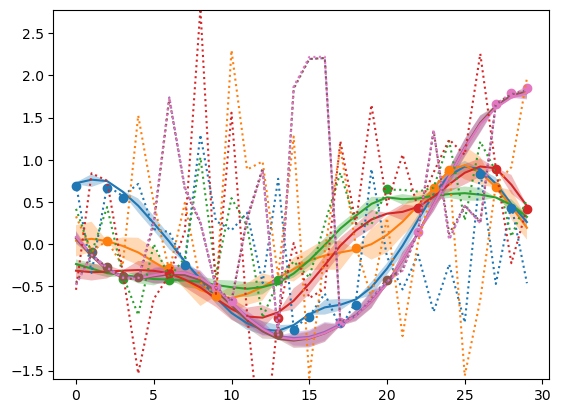

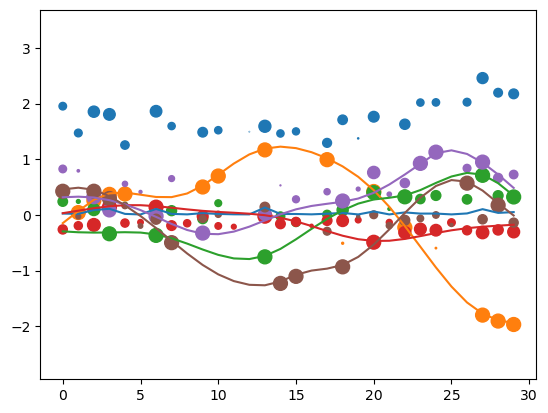

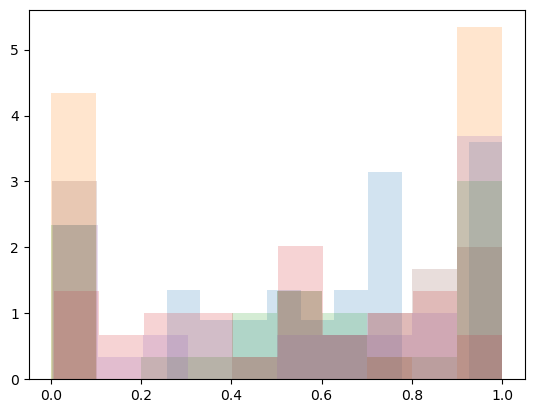

Epoch 17/500: Training Loss = 0.068891, Validation Loss = 0.147888


0it [00:00, ?it/s]

0.003623211057856679 0.13094663619995117


2it [00:00,  3.56it/s]

0.003163241781294346 0.17105749249458313


...

0.003428742289543152 0.14413638412952423


5it [00:02,  1.95it/s]

0.003057722235098481 0.13722261786460876


6it [00:02,  2.44it/s]


0.003569764783605933 0.17399893701076508
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


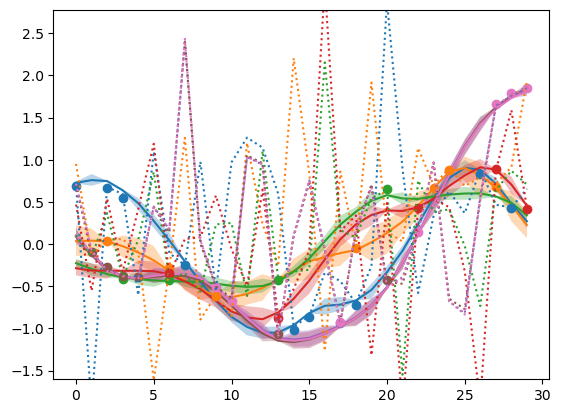

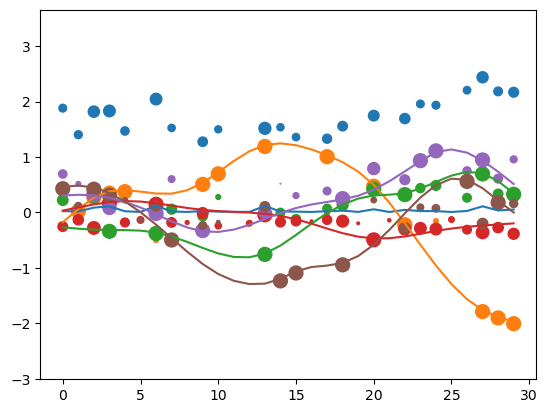

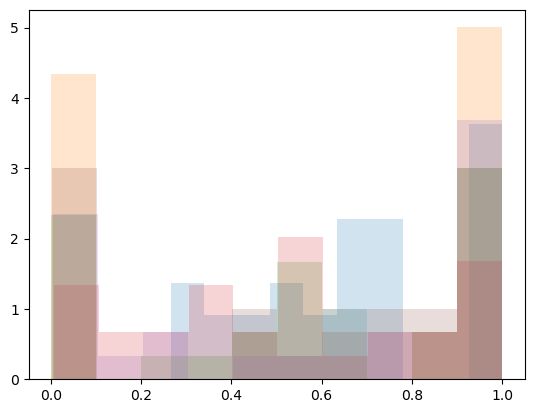

Epoch 18/500: Training Loss = 0.070043, Validation Loss = 0.145734


0it [00:00, ?it/s]

0.0032305431086570024 0.2086443305015564


2it [00:00,  4.11it/s]

0.0029382703360170126 0.13792330026626587


...

0.0030750243458896875 0.12119660526514053


5it [00:01,  3.49it/s]

0.00314756715670228 0.14454051852226257


6it [00:01,  3.95it/s]


0.003922972362488508 0.17373469471931458
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


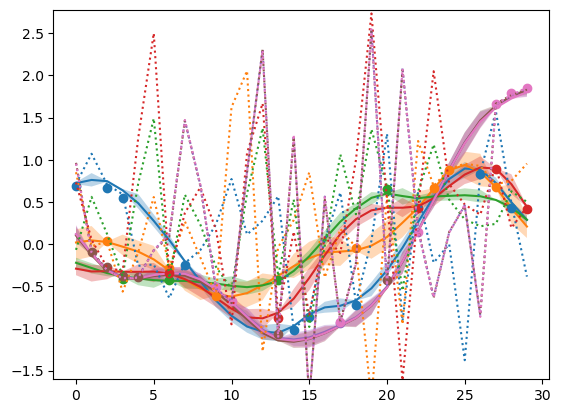

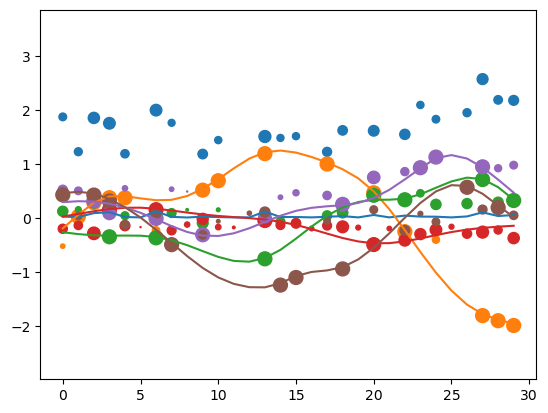

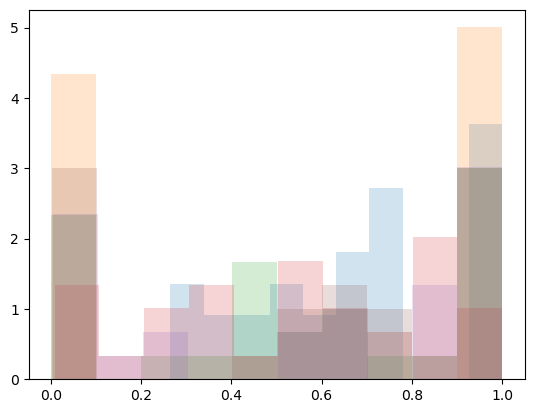

Epoch 19/500: Training Loss = 0.073838, Validation Loss = 0.158391


0it [00:00, ?it/s]

0.002963129198178649 0.15808866918087006


1it [00:00,  2.98it/s]

0.0038507343269884586 0.12822656333446503


...

0.0030137256253510714 0.12873002886772156


5it [00:01,  3.42it/s]

0.002977685770019889 0.15177340805530548


6it [00:01,  3.69it/s]


0.0028124279342591763 0.13526761531829834
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


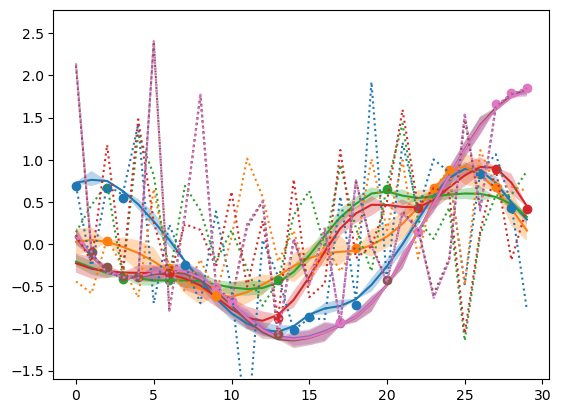

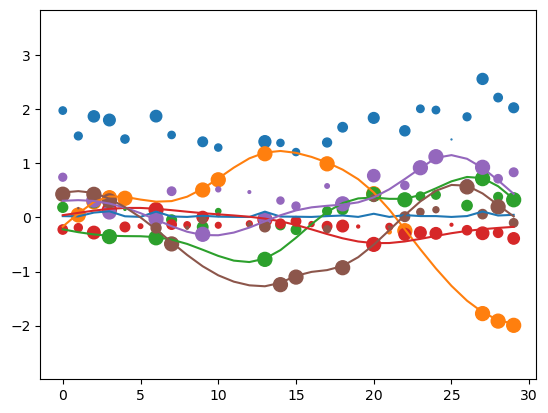

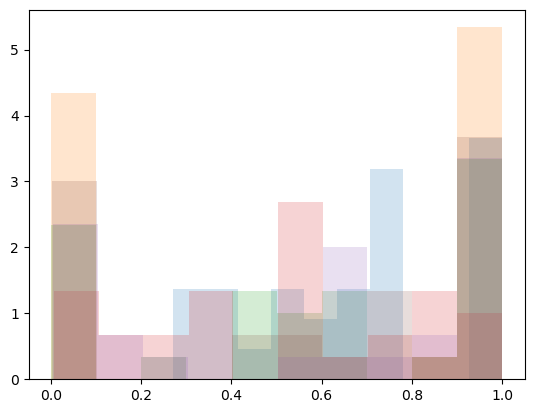

Epoch 20/500: Training Loss = 0.066936, Validation Loss = 0.150965


0it [00:00, ?it/s]

0.0031224903650581837 0.15712133049964905


1it [00:00,  3.48it/s]

0.0036822492256760597 0.18442998826503754


...

0.003071907442063093 0.14818203449249268


5it [00:01,  3.87it/s]

0.0032860494684427977 0.13121585547924042
0.002421183045953512 0.11069915443658829


6it [00:01,  4.02it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


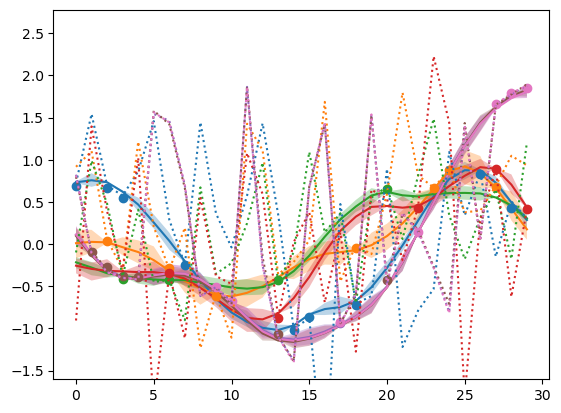

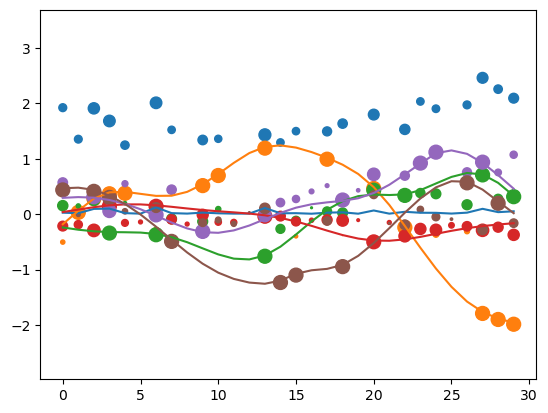

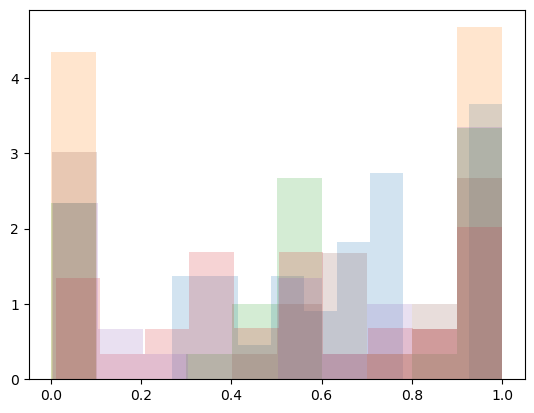

Epoch 21/500: Training Loss = 0.068562, Validation Loss = 0.162020


0it [00:00, ?it/s]

0.0037033928092569113 0.18987424671649933


2it [00:00,  2.33it/s]

0.00266940426081419 0.1550239473581314


...

0.0035458197817206383 0.13274835050106049


5it [00:01,  3.30it/s]

0.002757002366706729 0.14023149013519287


6it [00:01,  3.50it/s]


0.0028103271033614874 0.2081623673439026
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


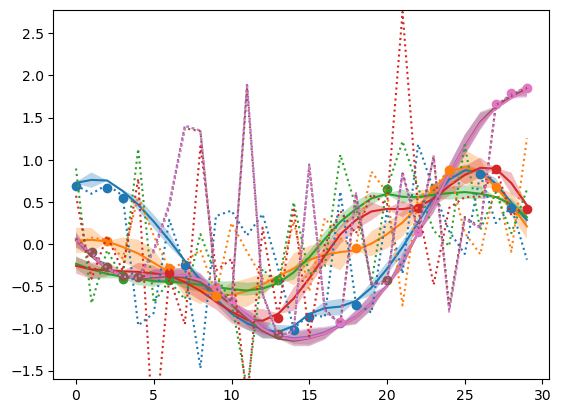

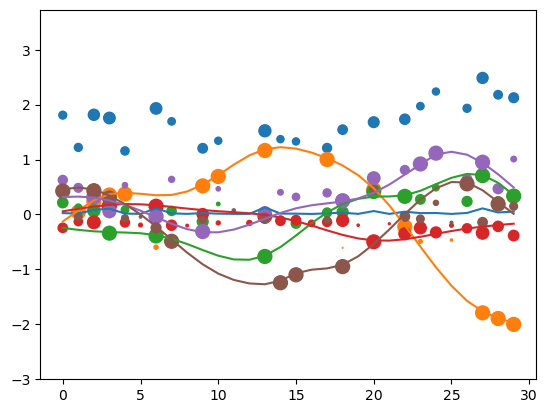

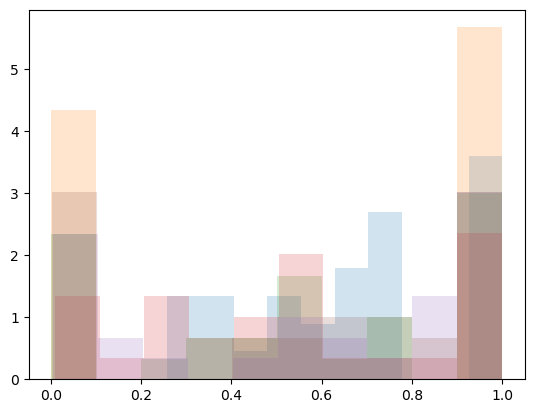

Epoch 22/500: Training Loss = 0.073328, Validation Loss = 0.147452


0it [00:00, ?it/s]

0.0030652277637273073 0.14019769430160522


2it [00:00,  3.99it/s]

0.003368771867826581 0.11574961245059967


...

0.003386808093637228 0.15021869540214539


5it [00:01,  3.99it/s]

0.0030800283420830965 0.18914705514907837
0.0037562213838100433 0.18117794394493103


6it [00:01,  4.39it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


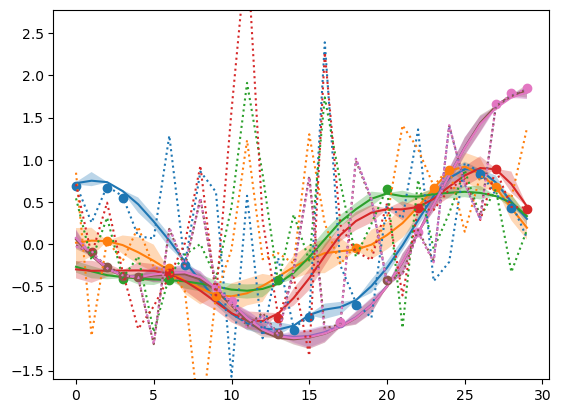

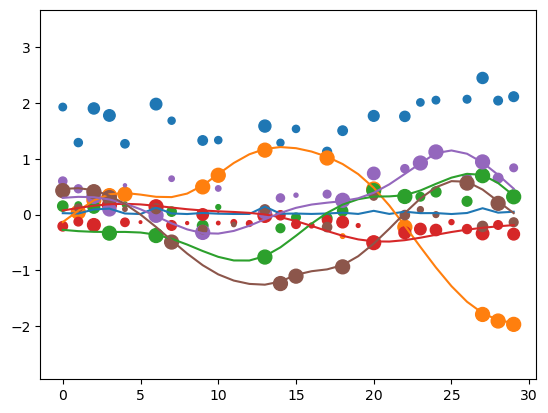

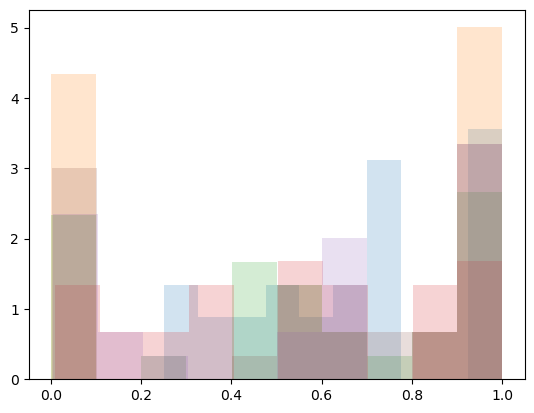

Epoch 23/500: Training Loss = 0.072110, Validation Loss = 0.158636


0it [00:00, ?it/s]

0.0034903499763458967 0.15242761373519897


2it [00:00,  4.04it/s]

0.002963688690215349 0.15480177104473114


...

0.003327032784000039 0.14593078196048737


5it [00:01,  4.02it/s]

0.00346325128339231 0.1870248019695282
0.002736627124249935 0.17380757629871368


6it [00:01,  4.40it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


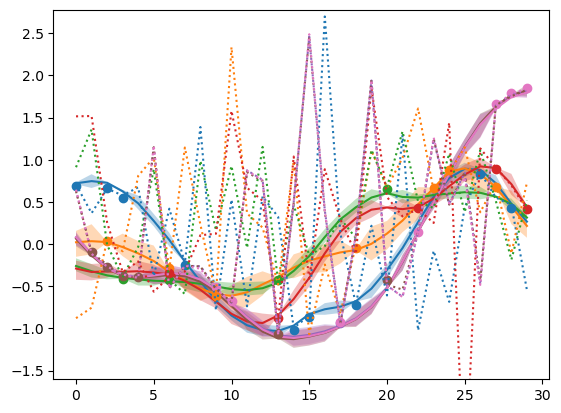

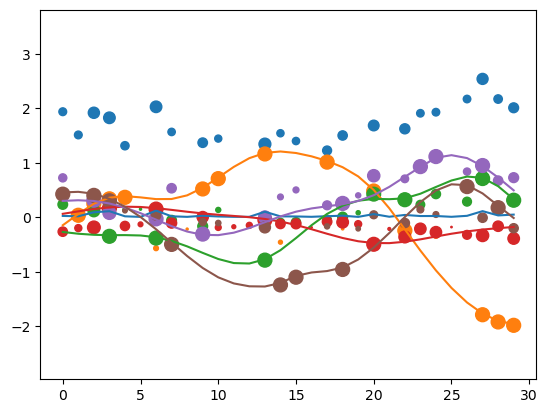

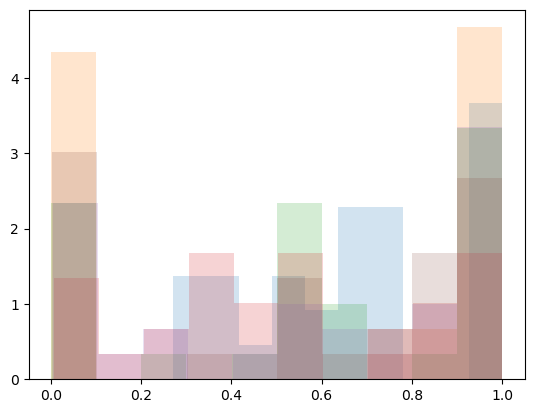

Epoch 24/500: Training Loss = 0.072233, Validation Loss = 0.160528


0it [00:00, ?it/s]

0.003926694393157959 0.15950323641300201


2it [00:00,  4.20it/s]

0.0032857083715498447 0.13771384954452515


...

0.003349700942635536 0.12990702688694


5it [00:01,  2.59it/s]

0.003475344507023692 0.18061910569667816
0.0029717383440583944 0.18085822463035583


6it [00:01,  3.50it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


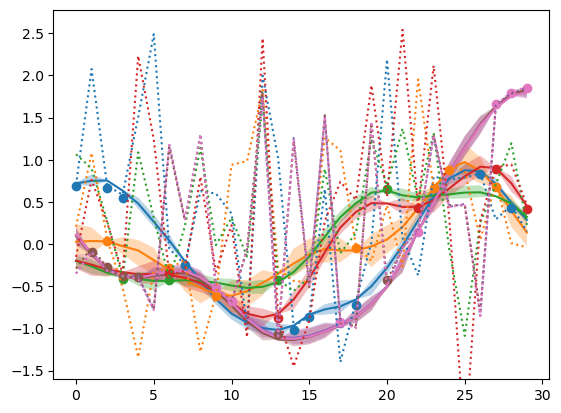

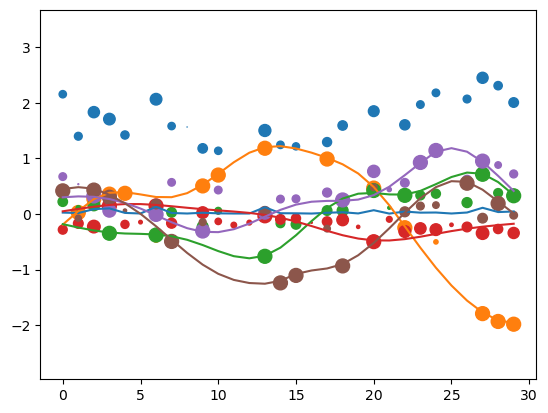

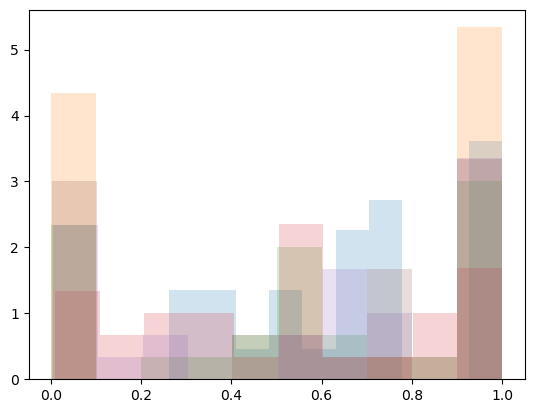

Epoch 25/500: Training Loss = 0.071462, Validation Loss = 0.149187


0it [00:00, ?it/s]

0.0033188362140208483 0.13064467906951904


2it [00:00,  4.28it/s]

0.0034894600976258516 0.17396771907806396


...

0.0032674300018697977 0.20260703563690186


5it [00:01,  3.78it/s]

0.003345643635839224 0.1741020828485489


6it [00:01,  4.21it/s]


0.002924615051597357 0.19129566848278046
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


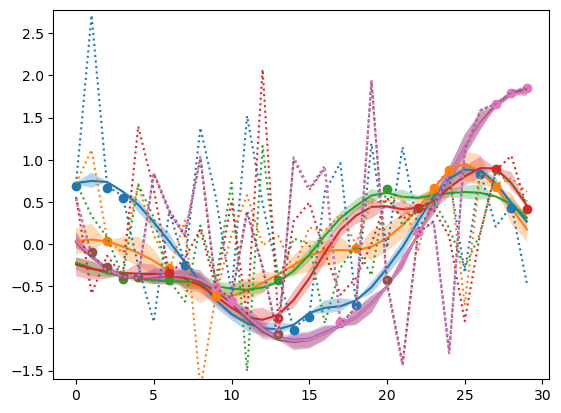

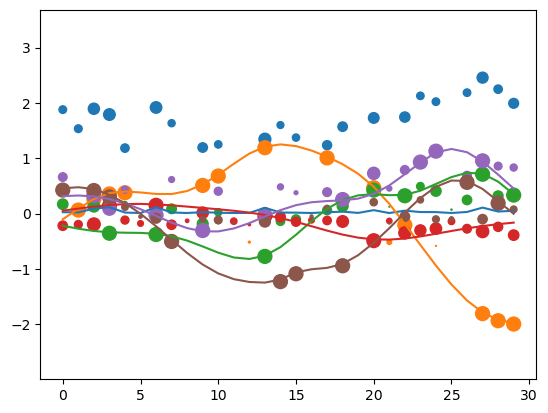

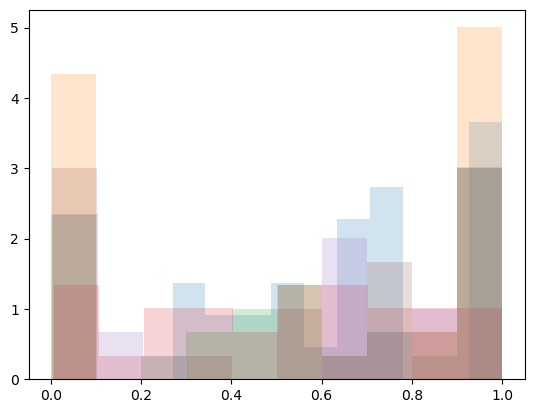

Epoch 26/500: Training Loss = 0.075396, Validation Loss = 0.152029


0it [00:00, ?it/s]

0.002941543934866786 0.16099350154399872


2it [00:00,  2.97it/s]

0.002989916130900383 0.15113836526870728


...

0.003636825829744339 0.16842100024223328
0.003492347663268447 0.18249787390232086


5it [00:01,  3.47it/s]

0.003255790565162897 0.14983020722866058
0.0030751044396311045 0.18848858773708344


6it [00:01,  3.76it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


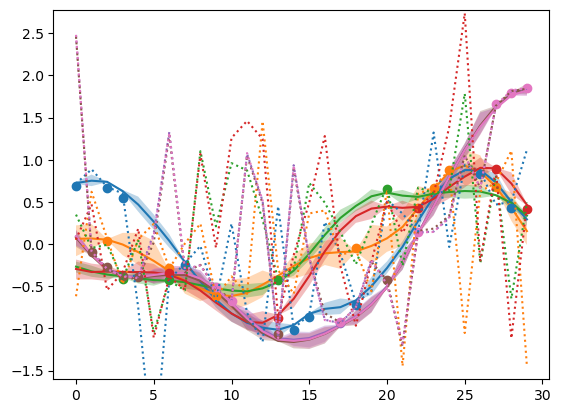

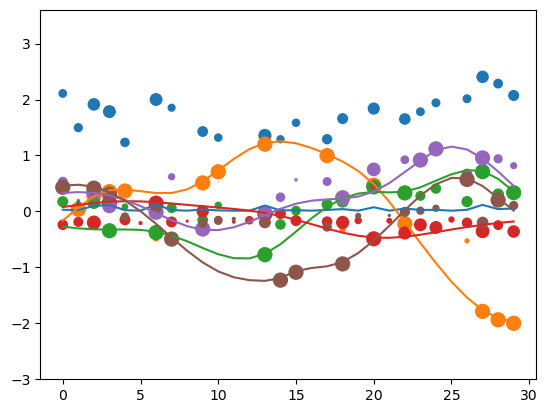

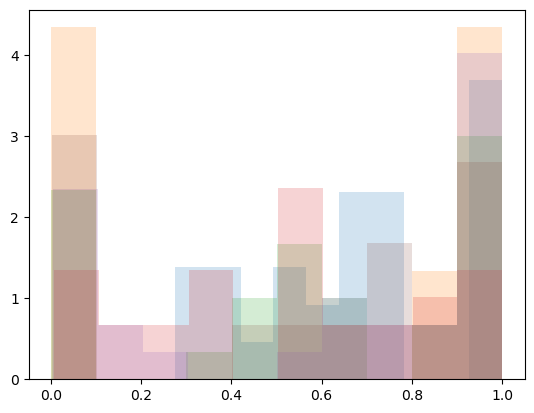

Epoch 27/500: Training Loss = 0.073723, Validation Loss = 0.151182


0it [00:00, ?it/s]

0.0025950090494006872 0.15227435529232025


2it [00:00,  3.59it/s]

0.003635936649516225 0.1933947652578354


...

0.0029904458206146955 0.13379065692424774


5it [00:01,  3.96it/s]

0.0034243017435073853 0.15477243065834045
0.0029347925446927547 0.10679170489311218


6it [00:01,  4.24it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


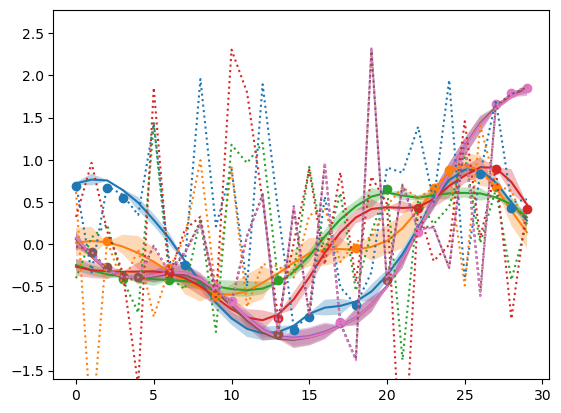

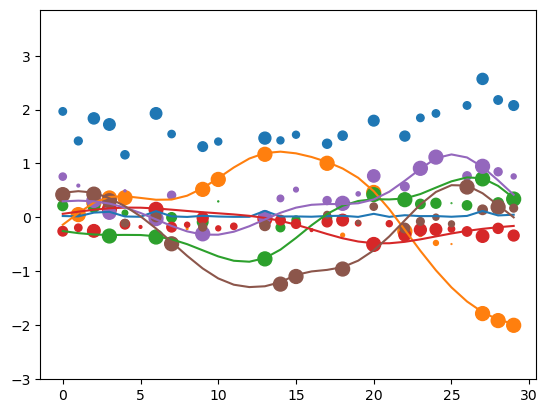

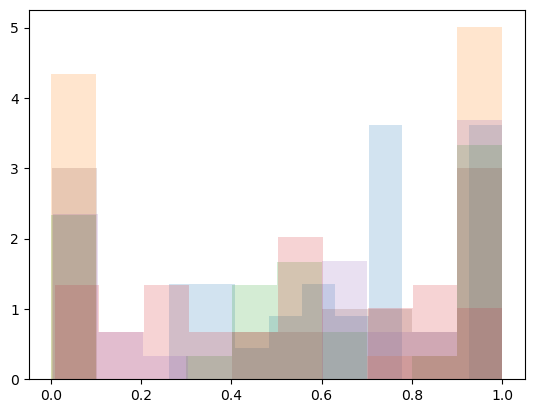

Epoch 28/500: Training Loss = 0.065788, Validation Loss = 0.155514


0it [00:00, ?it/s]

0.0036353743635118008 0.14307376742362976


2it [00:00,  2.99it/s]

0.002891457173973322 0.1526949107646942


...

0.0030562086030840874 0.23699882626533508


5it [00:01,  3.70it/s]

0.0038116644136607647 0.1459965854883194
0.003079839516431093 0.12609758973121643


6it [00:01,  3.97it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


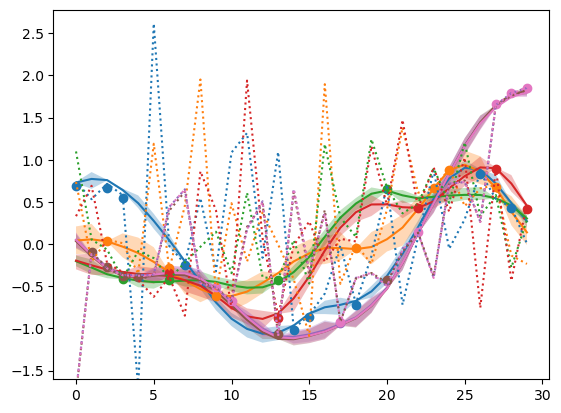

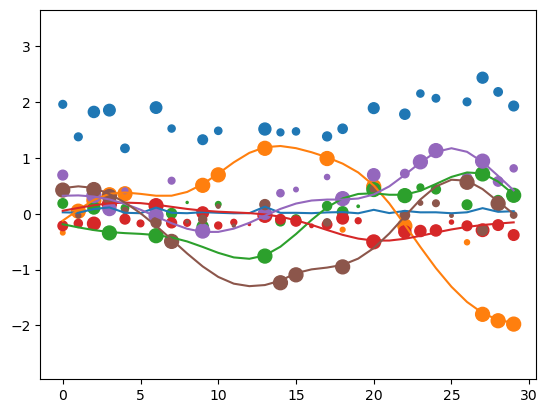

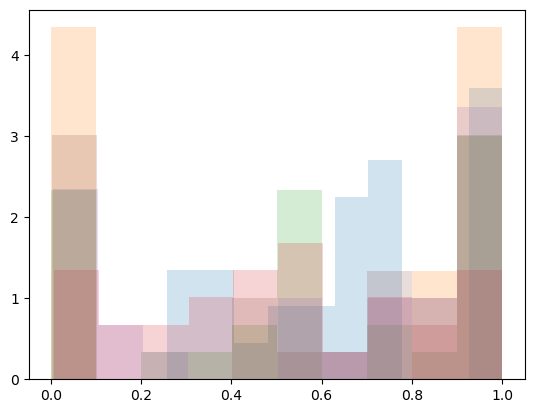

Epoch 29/500: Training Loss = 0.071081, Validation Loss = 0.153651


0it [00:00, ?it/s]

0.002711107488721609 0.1252872496843338


2it [00:00,  3.93it/s]

0.0033037695102393627 0.18814820051193237


...

0.0032850350253283978 0.16675834357738495


5it [00:01,  4.12it/s]

0.0030661087948828936 0.1623537689447403
0.0030186085496097803 0.1580282300710678


6it [00:01,  4.49it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


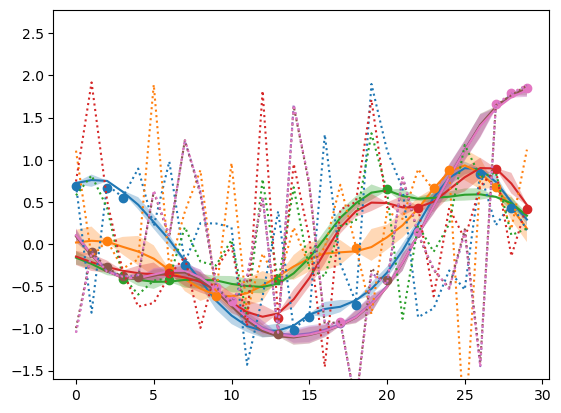

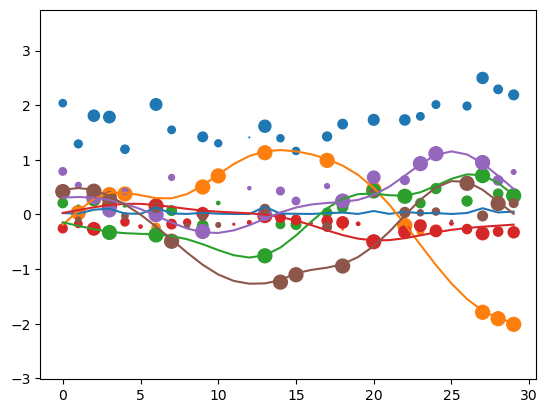

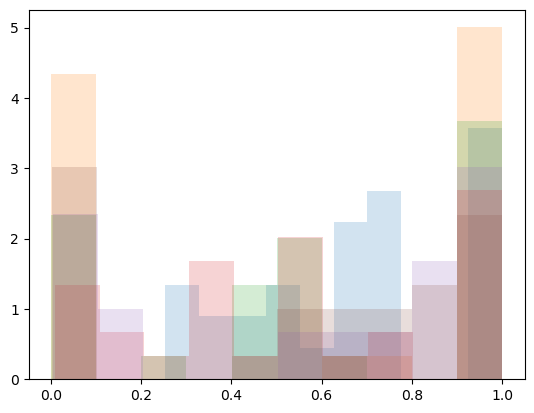

Epoch 30/500: Training Loss = 0.070327, Validation Loss = 0.151049


0it [00:00, ?it/s]

0.0036488045006990433 0.13875985145568848


2it [00:00,  4.29it/s]

0.003034377470612526 0.1724240779876709


...

0.0032108044251799583 0.22817154228687286


5it [00:01,  4.18it/s]

0.002632798394188285 0.13444875180721283
0.003062342992052436 0.13268409669399261


6it [00:01,  4.59it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


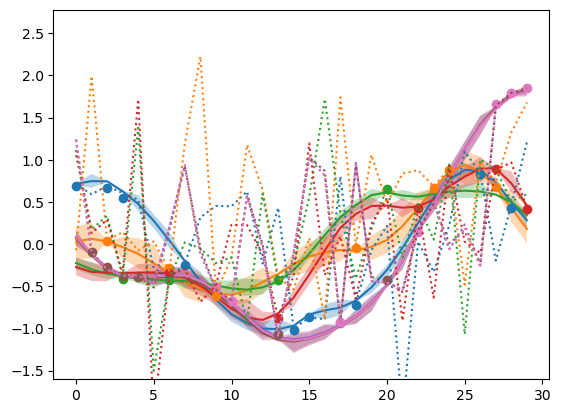

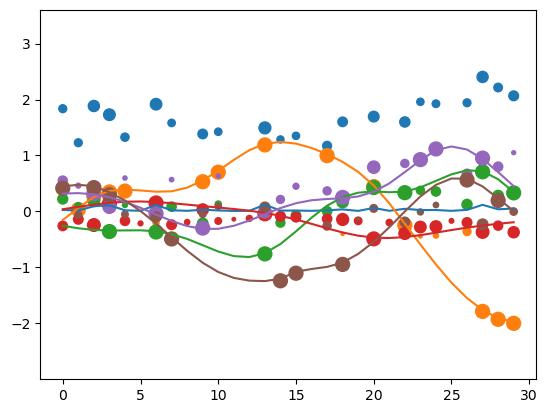

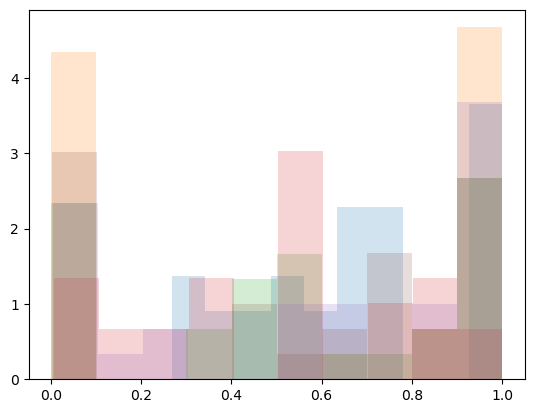

Epoch 31/500: Training Loss = 0.070076, Validation Loss = 0.168582


0it [00:00, ?it/s]

0.00270858034491539 0.15238122642040253


2it [00:00,  4.35it/s]

0.0036163488402962685 0.16225558519363403


...

0.003138134488835931 0.14117522537708282


5it [00:01,  4.13it/s]

0.0035904988180845976 0.18159767985343933
0.0023267557844519615 0.15931425988674164


6it [00:01,  4.55it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


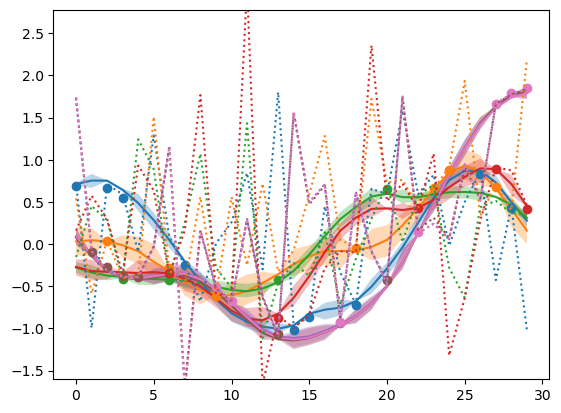

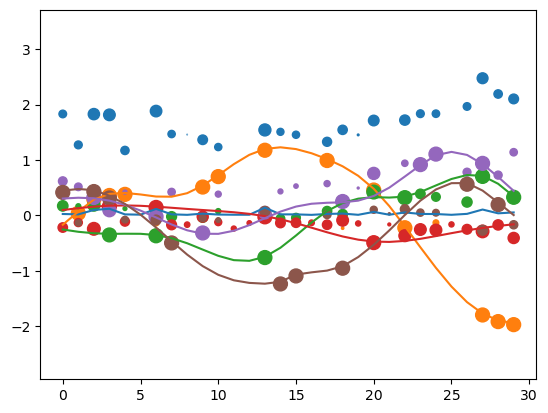

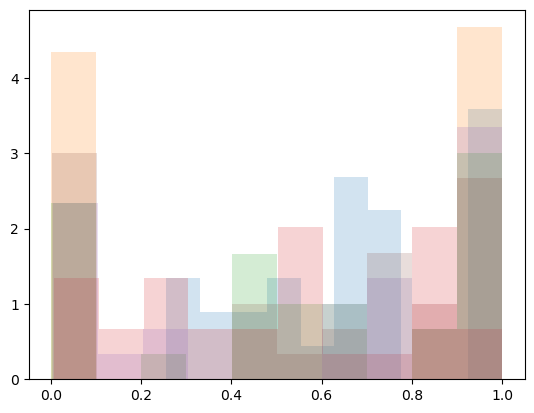

Epoch 32/500: Training Loss = 0.072190, Validation Loss = 0.147291


1it [00:00,  1.81it/s]

0.0028942441567778587 0.1651238203048706


2it [00:00,  2.47it/s]

0.0030072678346186876 0.1275949776172638


...

0.0033075695391744375 0.16251622140407562


5it [00:01,  3.50it/s]

0.0033085220493376255 0.17991027235984802


6it [00:01,  3.46it/s]


0.0039025158621370792 0.15308815240859985
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


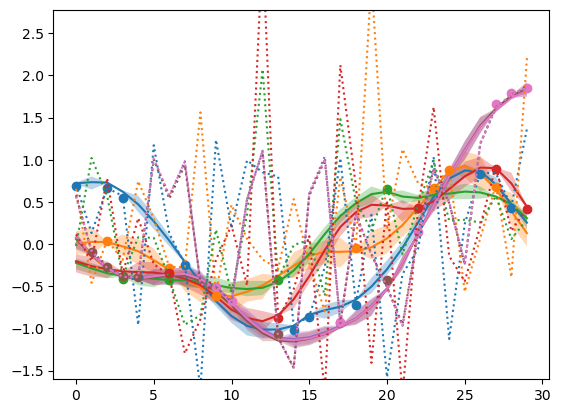

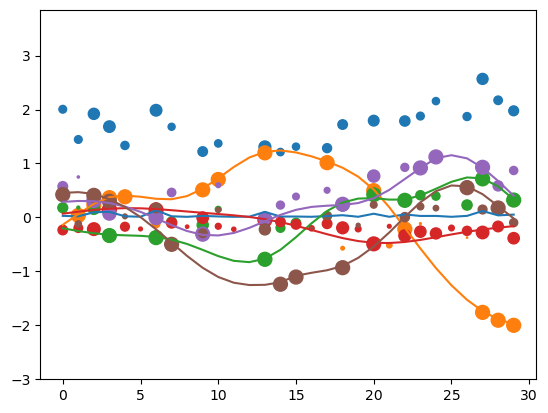

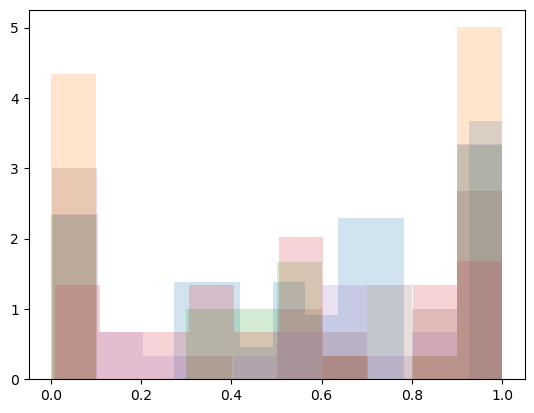

Epoch 33/500: Training Loss = 0.069607, Validation Loss = 0.152667


0it [00:00, ?it/s]

0.002983748447149992 0.14363189041614532


2it [00:00,  4.04it/s]

0.003448539413511753 0.12949272990226746


...

0.0034079859033226967 0.16442932188510895


5it [00:01,  3.97it/s]

0.002578842919319868 0.16802336275577545


6it [00:01,  4.35it/s]


0.0025997150223702192 0.15572847425937653
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


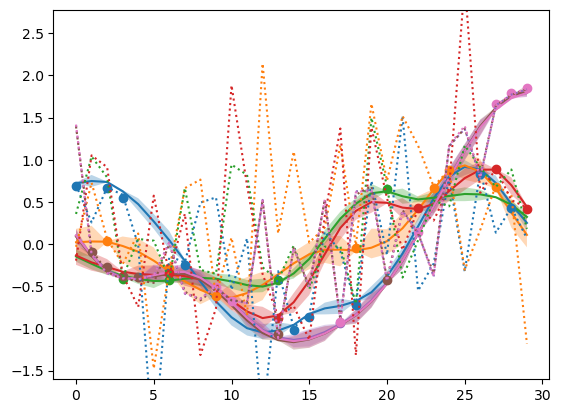

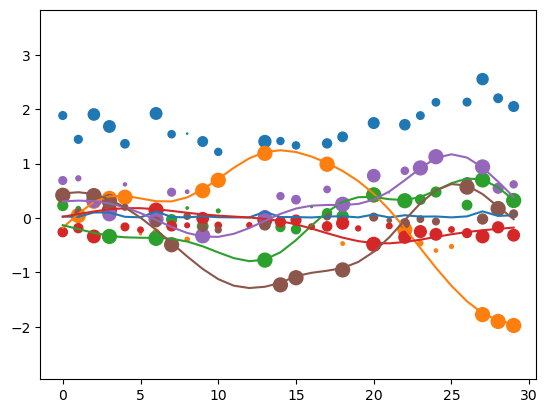

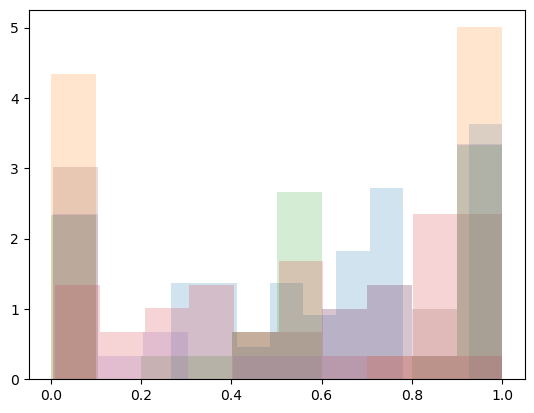

Epoch 34/500: Training Loss = 0.067231, Validation Loss = 0.150016


0it [00:00, ?it/s]

0.0035654413513839245 0.16781605780124664


2it [00:00,  3.99it/s]

0.0038074152544140816 0.14661774039268494


...

0.003298766678199172 0.15569718182086945


5it [00:01,  4.07it/s]

0.002832188969478011 0.12840944528579712
0.0030430832412093878 0.13388708233833313


6it [00:01,  4.43it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


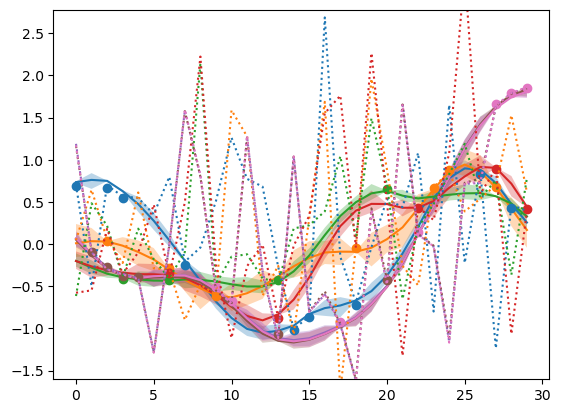

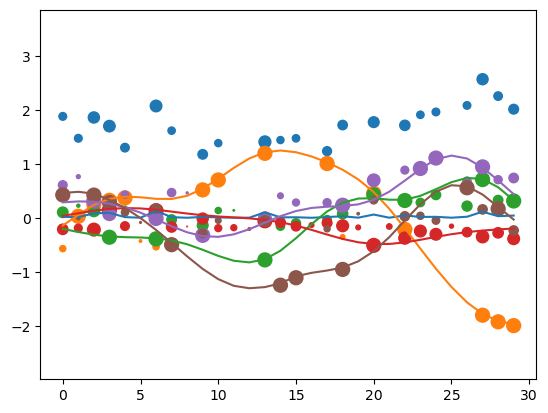

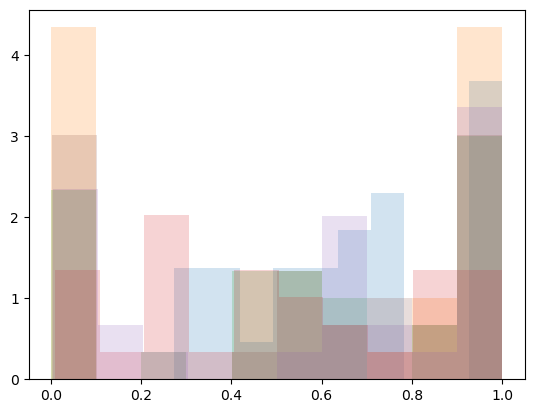

Epoch 35/500: Training Loss = 0.067446, Validation Loss = 0.149341


0it [00:00, ?it/s]

0.0030630757100880146 0.16027064621448517


2it [00:00,  4.00it/s]

0.0024992250837385654 0.1496368646621704


...

0.0030843133572489023 0.16943144798278809


5it [00:01,  3.36it/s]

0.003420840483158827 0.14645567536354065
0.003388478420674801 0.13067953288555145


6it [00:01,  3.85it/s]


torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([64, 30, 7]) torch.Size([64, 30, 7])
torch.Size([22, 30, 7]) torch.Size([22, 30, 7])


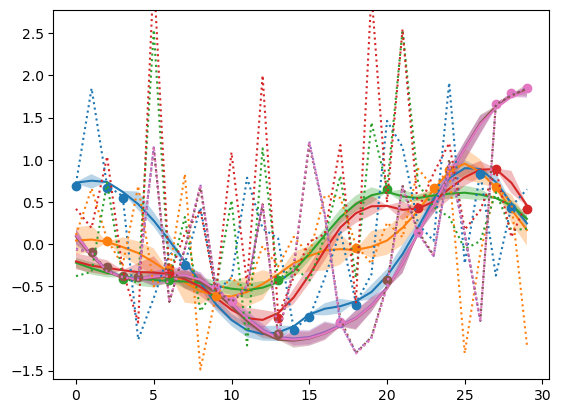

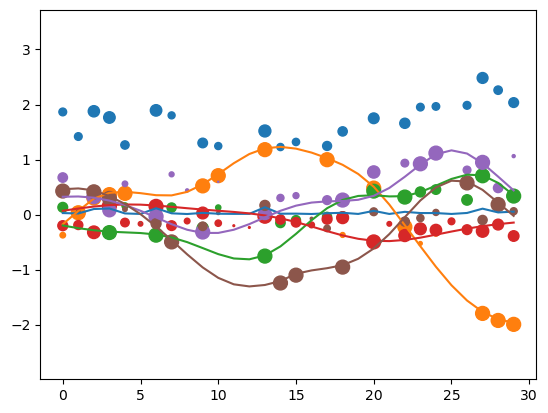

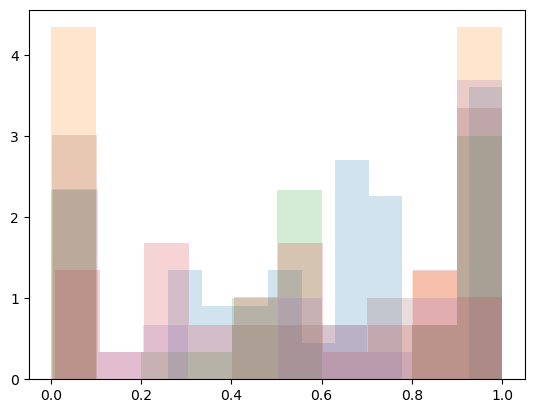

2025-03-18 13:53:12 [INFO]: Exceeded the training patience. Terminating the training procedure...
2025-03-18 13:53:12 [INFO]: Finished training. The best model is from epoch#5.


Epoch 36/500: Training Loss = 0.069655, Validation Loss = 0.152745


In [ ]:
gpuae.fit(dataset_train_nan, dataset_val_nan, train_kernel_only = True)  # train the model on the dataset

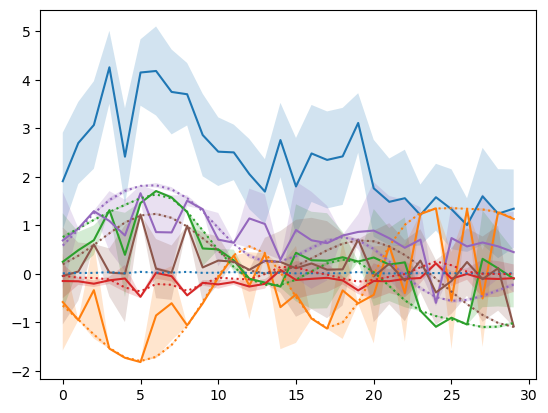

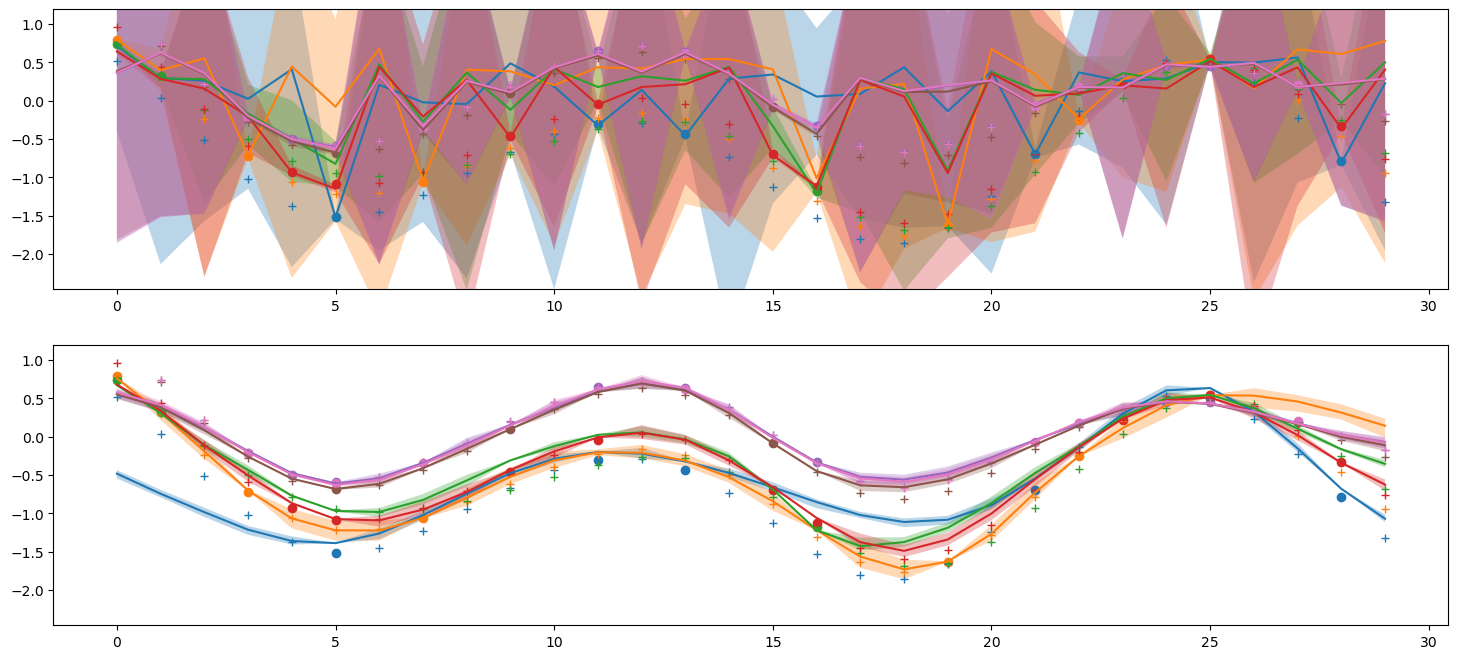

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

i = 3
alpha = .5

X_ori = torch.tensor(dataset_val_nan['X_ori']).float()

X_corr = torch.tensor(dataset_val_nan['X']).float()
X_corr[X_corr!=X_corr] = 0.

qz_x_corr = gpuae.model.backbone.encoder(X_corr)

# correct
kernel_params = gpuae.gp.update_kernel_params(X_corr)
qz_star = gpuae.gp.correct_qz_x_with_gp(qz_x_corr, kernel_params)

# plot reconstructions

kernel_params = gpuae.gp.update_kernel_params(X_corr)
qz_star = gpuae.gp.correct_qz_x_with_gp(qz_x_corr, kernel_params)

plot_multi_gaussian(qz_x_corr, alpha = 1)
plot_multi_gaussian(qz_star, alpha = 1, linestyle = ':')
plt.show();

fig, ax = plt.subplots(2, figsize=(18,8))

i = 4
plot_reconstructions(X_corr, X_ori, qz_star, gpuae, ax = ax[1], i = i)
plot_reconstructions(X_corr, X_ori, qz_x_corr, gpuae, ax = ax[0], i = i)

In [ ]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = gpuae.predict(dataset_val_nan, with_gp = True)
imputation = np.array(results['imputation'])
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

0.20415144610379324

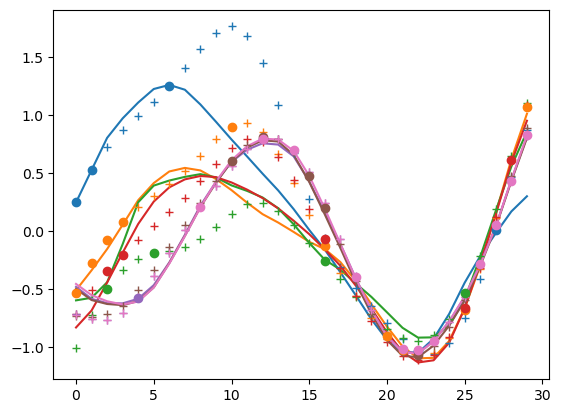

In [ ]:
import matplotlib.pyplot as plt

i = 1
plt.plot(imputation[i]);
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X_ori'][i],'+');
plt.gca().set_prop_cycle(None)
plt.plot(dataset_val_nan['X'][i],'o');

In [ ]:
from pypots.utils.metrics import calc_mae
import numpy as np

results = saits.predict(dataset_val_nan)
imputation = np.array(results['imputation'])
calc_mae(imputation, dataset_val_nan['X_ori'], (dataset_val_nan['X_ori']==dataset_val_nan['X_ori']))

0.2124740792966812

In [ ]:
saits.fit(train_set=dataset_train_nan, val_set=dataset_val_nan)  # train the model on the dataset

2025-03-18 11:22:01 [INFO]: Epoch 001 - training loss: 1.5616, validation loss: 0.7353
2025-03-18 11:22:02 [INFO]: Epoch 002 - training loss: 1.1435, validation loss: 0.5643
2025-03-18 11:22:03 [INFO]: Epoch 003 - training loss: 1.0097, validation loss: 0.4844
2025-03-18 11:22:03 [INFO]: Epoch 004 - training loss: 0.9435, validation loss: 0.3952
2025-03-18 11:22:04 [INFO]: Epoch 005 - training loss: 0.8781, validation loss: 0.3298
2025-03-18 11:22:05 [INFO]: Epoch 006 - training loss: 0.8188, validation loss: 0.2687
2025-03-18 11:22:05 [INFO]: Epoch 007 - training loss: 0.7677, validation loss: 0.2302
2025-03-18 11:22:06 [INFO]: Epoch 008 - training loss: 0.7214, validation loss: 0.2176
2025-03-18 11:22:07 [INFO]: Epoch 009 - training loss: 0.7213, validation loss: 0.2156
2025-03-18 11:22:07 [INFO]: Epoch 010 - training loss: 0.6989, validation loss: 0.2005
2025-03-18 11:22:08 [INFO]: Epoch 011 - training loss: 0.6962, validation loss: 0.1976
2025-03-18 11:22:09 [INFO]: Epoch 012 - tra